# $\color{cyan}{\text{Imports and Setup}}$

## $\color{yellow}{\text{Imports}}$

In [1]:
# Enables automatic reloading of local analysis modules during notebook development
%load_ext autoreload

# Configures the autoreload extension to reload all modules before executing code
%autoreload 2

In [2]:
# Import required packages
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scripts.sync import run_sync
from scripts.data_loader import load_titan_data
from scripts.setup_functions import update_immob_flags, calculate_5s_averages, run_pel_analysis, run_immob_analysis, run_standard_curve_analysis, four_pl, five_pl, analyse_standard_curves_extra
from scripts.analysis_functions import analyse_pel, analyse_immob_split, plot_pel_layer_shifts, combine_anomalies, analyse_cross_stage_split, cross_stage_correlations, create_interactive_dashboard, prepare_ensemble_section, generate_at_risk_summary, run_binding_kinetics_analysis

## $\color{yellow}{\text{Setup}}$

In [3]:
# Configures pandas to show all dataframe columns without truncation
pd.set_option('display.max_columns', None)

### $\color{gold}{\text{Database Loading}}$

In [4]:
# Downloads datasets from the remote database (commented out to prevent redundant runs)
#run_sync()

In [5]:
# Load the processed Titan tables and storage-bucket datasets
tables, bucket_data = load_titan_data()

Loading database tables...
Loading table: amf_turns
Loading table: backend_event_log
Loading table: backend_event_log_archive
EMPTY FILE SKIPPED: backend_event_log_archive.csv
Loading table: chip_calibrations
Loading table: chip_calibration_spetrca
Loading table: chip_labelling
EMPTY FILE SKIPPED: chip_labelling.csv
Loading table: chip_status
Loading table: comments
Loading table: device
Loading table: experiments
Loading table: experiment_chips
Loading table: experiment_standard_curves
Loading table: flagged_items
Loading table: flags
Loading table: immob
Loading table: machine
Loading table: measurements
Loading table: notifications
Loading table: optical_reference_spectra
Loading table: pel_upload
Loading table: qc_baseline_drift
Loading table: qc_measurements
Loading table: sensorgram_history
Loading table: standard_curves
Loading table: standard_curve_history
Loading table: system_utilization_log
Loading table: uploads
Loading table: users
Loading and filtering bucket data...
SKIP

# $\color{cyan}{\text{Initial Checks}}$

---

## $\color{yellow}{\text{Average Flag Check}}$

In [6]:
# Evaluates whether the averaged immobilisation flags dictionary exists in the bucket data
if 'averaged_flags' not in bucket_data:

    # Initialises an empty dictionary to store averaged immobilisation flags
    bucket_data['averaged_flags'] = {}

## $\color{yellow}{\text{Channel Check}}$

### $\color{red}{\text{Setup}}$

In [7]:
def evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False):
    '''Validates matched PEL and immobilisation data for channel-order swaps.
    Standardizes both datasets so Ch1 < Ch2 first, prints standalone metrics, 
    and then performs cross-stage matching and secondary fixes.

    Args:
        tables (dict): Loaded database tables containing experiment metadata.
        bucket_data (dict): Loaded sensorgram and RefPoly4 file data.
        fix_mistakes (bool, optional): Whether detected swaps should be corrected in memory. Defaults to False.

    Returns:
        None: Results are reported to standard output and optional corrections are applied in place.
    '''

    # Initialises variables to count general PEL channel ordering
    all_pel_ch1_less = 0
    all_pel_ch2_less = 0
    all_pel_equal = 0
    total_pel_processed = 0
    total_pel_swapped = 0

    # Initialises variables to count general immobilisation channel ordering
    all_immob_ch1_less = 0
    all_immob_ch2_less = 0
    all_immob_equal = 0
    total_immob_processed = 0
    total_immob_swapped = 0

    # Initialises variables to count successfully matched channel ordering between stages
    matched_pel_ch1_less = 0
    matched_pel_ch2_less = 0
    matched_pel_equal = 0
    matched_immob_ch1_less = 0
    matched_immob_ch2_less = 0
    matched_immob_equal = 0
    total_matched = 0

    # Initialises total variables for the cross-stage channel-order comparison
    total_less_more = 0
    total_more_less = 0
    total_less = 0
    total_more = 0

    # Initialises variables to count explained and unexplained channel swaps
    crossovers_explained_by_chemistry = 0
    crossovers_unexplained_true_swaps = 0

    # Initialises a list to track chip identifiers with chemistry-explained crossovers
    ch1_chemistry_chips = []

    # Initialises a list to track chip identifiers with unexplained true swaps
    ch1_unexplained_chips = []

    # Initialises a list to track chip identifiers with identical final values
    ch1_same_chips = []

    # =========================================================================
    # STEP 1: CHECK PEL, SWAP IN-PLACE, AND UPDATE CHANNELS
    # =========================================================================
    
    # Loops through each row in the PEL upload dataframe
    for index, pel_row in tables['pel_upload'].iterrows():

        # Extracts the flags identifier for the current record
        flags_id = pel_row['flags_id']

        # Extracts the sensorgram file identifier for the current record
        sensorgram_file = pel_row['sensorgram']

        # Evaluates whether the sensorgram file exists in the bucket data
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):

            # Skips to the next record if the sensorgram file is missing
            continue
            
        # Filters the flags table to retrieve records matching the current flags identifier
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Evaluates whether the extracted flag dataframe contains data
        if pel_flags.empty:

            # Skips to the next record if no flags are found
            continue

        # Retrieves the raw sensorgram dataframe corresponding to the current file
        file_data = bucket_data['Sensorgram'][sensorgram_file]

        # Extracts the initial PEL start time, handling both scalar and series formats
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        
        # Interpolates the primary channel signal at the extracted start time
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])

        # Interpolates the secondary channel signal at the extracted start time
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        # Evaluates whether the primary channel starts lower than the secondary channel
        if pel_start_1 < pel_start_2:

            # Increments the counter for lower primary channels
            all_pel_ch1_less += 1

        # Evaluates whether the primary channel starts higher than the secondary channel
        elif pel_start_1 > pel_start_2:

            # Increments the counter for higher primary channels
            all_pel_ch2_less += 1

            # Evaluates whether the function is configured to actively fix detected mistakes
            if fix_mistakes:

                # Overwrites the incorrect channel data in memory by swapping the columns
                bucket_data['Sensorgram'][sensorgram_file][['quad_ch1', 'quad_ch2']] = bucket_data['Sensorgram'][sensorgram_file][['quad_ch2', 'quad_ch1']]

                # Increments the total count of corrected PEL files
                total_pel_swapped += 1

        # Handles cases where both channels start at the identical value
        else:

            # Increments the counter for equal channels
            all_pel_equal += 1
            
        # Increments the total count of processed PEL records
        total_pel_processed += 1

    # =========================================================================
    # STEP 2: CHECK IMMOB, SWAP IN-PLACE, AND UPDATE CHANNELS
    # =========================================================================
    
    # Loops through each row in the immobilisation dataframe
    for index, immob_row in tables['immob'].iterrows():

        # Extracts the immobilisation flags file identifier
        immob_flags_file = immob_row['amfFlags']

        # Extracts the RefPoly4 file identifier
        refpoly4_file = immob_row['refPoly4']

        # Evaluates whether the required flag and sensorgram files are present in the bucket data
        if immob_flags_file not in bucket_data.get('AMF_FLAGS', {}) or refpoly4_file not in bucket_data.get('RefPoly4', {}):

            # Skips to the next record if required files are missing
            continue

        # Retrieves the relevant flag dataframe for the current immobilisation record
        immob_flags = bucket_data['AMF_FLAGS'][immob_flags_file]

        # Retrieves the relevant sensorgram dataframe for the current immobilisation record
        immob_data = bucket_data['RefPoly4'][refpoly4_file]

        # Evaluates whether the immobilisation flags dataframe contains valid structure and information
        if immob_flags.empty or 'information' not in immob_flags.columns:

            # Skips to the next record if the flags dataframe is invalid
            continue

        # Filters the flag dataframe to isolate the initial baseline flag
        initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]

        # Evaluates whether initial flags are missing, indicating unprocessed data
        if initial_flags.empty:

            # Prints a progress message indicating flag calculation is commencing
            print(f'Calculating and updating buffer, plateau and baseline flags for {immob_flags_file}...')

            # Constructs the file path to save the calculated baseline flags
            flags_file_path = os.path.join('data/buckets/AMF_FLAGS', immob_flags_file)

            # Constructs the file path to save the calculated averaged flags
            avg_file_path = os.path.join('data/buckets/averaged_flags', immob_flags_file)

            # Executes the calculation to generate and update all required immobilisation flags
            immob_flags = update_immob_flags(immob_flags, immob_data, file_path=flags_file_path)

            # Replaces the raw flag dataframe with the updated version in memory
            bucket_data['AMF_FLAGS'][immob_flags_file] = immob_flags

            # Prints a progress message indicating five-second averaging is commencing
            print(f'Calculating 5-second averages for {immob_flags_file}...')

            # Executes the calculation to generate five-second averages across all flags
            avg_flags = calculate_5s_averages(immob_flags, immob_data, file_path=avg_file_path)

            # Evaluates whether the averaged flags dictionary is present
            if 'averaged_flags' in bucket_data:

                # Stores the generated averaged flags in the bucket data memory
                bucket_data['averaged_flags'][immob_flags_file] = avg_flags

            # Re-evaluates the initial flags variable using the newly updated dataframe
            initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]
            
        # Checks whether initial flags remain missing after the calculation process
        if initial_flags.empty:

            # Skips to the next record if initial flags cannot be resolved
            continue
            
        # Extracts the timestamp of the initial immobilisation flag
        immob_initial_time = initial_flags['time'].iloc[0]

        # Interpolates the primary channel signal at the initial immobilisation time
        immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])

        # Interpolates the secondary channel signal at the initial immobilisation time
        immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

        # Evaluates whether the primary channel starts lower than the secondary channel in immobilisation
        if immob_start_1 < immob_start_2:

            # Increments the counter for lower primary channels
            all_immob_ch1_less += 1

        # Evaluates whether the primary channel starts higher than the secondary channel in immobilisation
        elif immob_start_1 > immob_start_2:

            # Increments the counter for higher primary channels
            all_immob_ch2_less += 1

            # Evaluates whether the function is configured to actively fix detected mistakes
            if fix_mistakes:

                # Overwrites the incorrect channel data in the bucket memory by swapping the columns
                bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]

                # Increments the total count of corrected immobilisation files
                total_immob_swapped += 1

        # Handles cases where both channels start at the identical value
        else:

            # Increments the counter for equal channels
            all_immob_equal += 1
            
        # Increments the total count of processed immobilisation records
        total_immob_processed += 1

    # =========================================================================
    # STEP 3: PRINT STANDALONE METRICS FOR ALL PEL AND ALL IMMOB RECORDS
    # =========================================================================
    
    # Prints the total valid PEL records successfully processed
    print(f'Total Valid PEL Records Processed: {total_pel_processed}')

    # Prints the total valid immobilisation records successfully processed
    print(f'Total Valid Immob Records Processed: {total_immob_processed}')

    # Prints the header for the general PEL breakdown
    print('\n1. PEL (at Start Flag for ALL valid PEL records)')

    # Prints the count of PEL records where primary channel is lower
    print(f'Ch1 < Ch2: {all_pel_ch1_less}')

    # Prints the count of PEL records where primary channel is higher
    print(f'Ch1 > Ch2: {all_pel_ch2_less}')

    # Prints the count of PEL records where channels are equal
    print(f'Ch1 = Ch2: {all_pel_equal}')

    # Prints the header for the general immobilisation breakdown
    print('\n2. Immob (at Initial Flag for ALL valid Immob records)')

    # Prints the count of immobilisation records where primary channel is lower
    print(f'Ch1 < Ch2: {all_immob_ch1_less}')

    # Prints the count of immobilisation records where primary channel is higher
    print(f'Ch1 > Ch2: {all_immob_ch2_less}')

    # Prints the count of immobilisation records where channels are equal
    print(f'Ch1 = Ch2: {all_immob_equal}')

    # =========================================================================
    # STEP 4: CHECK BETWEEN THEM (MATCH), FIX REMAINING ISSUES, & PRINT COMPARISONS
    # =========================================================================
    
    # Loops through each row in the immobilisation dataframe to perform cross-stage matching
    for index, immob_row in tables['immob'].iterrows():

        # Extracts the chip identifier for the current row
        chip_id = immob_row['chip_id']

        # Extracts the immobilisation flags file identifier
        immob_flags_file = immob_row['amfFlags']

        # Extracts the RefPoly4 file identifier
        refpoly4_file = immob_row['refPoly4']

        # Evaluates whether the required files exist in the bucket memory
        if immob_flags_file not in bucket_data.get('AMF_FLAGS', {}) or refpoly4_file not in bucket_data.get('RefPoly4', {}):

            # Skips to the next record if files are missing
            continue

        # Retrieves the immobilisation flags dataframe
        immob_flags = bucket_data['AMF_FLAGS'][immob_flags_file]

        # Retrieves the immobilisation sensorgram dataframe
        immob_data = bucket_data['RefPoly4'][refpoly4_file]

        # Evaluates whether the flags dataframe contains valid data
        if immob_flags.empty or 'information' not in immob_flags.columns:

            # Skips to the next record if data is missing
            continue

        # Filters the flag dataframe to isolate the initial baseline flag
        initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]

        # Evaluates whether the initial flag was found
        if initial_flags.empty:

            # Skips to the next record if the flag is missing
            continue

        # Searches the PEL upload dataframe for a matching chip identifier
        pel_match = tables['pel_upload'][tables['pel_upload']['chip_id'] == chip_id]

        # Evaluates whether a corresponding PEL record exists
        if pel_match.empty:

            # Skips to the next record if no match is found
            continue

        # Extracts the matched PEL metadata row
        pel_row = pel_match.iloc[0]

        # Extracts the flags identifier from the matched PEL record
        flags_id = pel_row['flags_id']

        # Extracts the sensorgram file identifier from the matched PEL record
        sensorgram_file = pel_row['sensorgram']

        # Evaluates whether the matched sensorgram file exists in the bucket data
        if sensorgram_file not in bucket_data.get('Sensorgram', {}):

            # Skips to the next record if the file is missing
            continue

        # Retrieves the associated PEL flags from the database tables
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        # Evaluates whether the matched PEL flag dataframe contains data
        if pel_flags.empty:

            # Skips to the next record if the flags are empty
            continue

        # Retrieves the raw PEL sensorgram data
        file_data = bucket_data['Sensorgram'][sensorgram_file]

        # Increments the successfully matched records counter
        total_matched += 1

        # Extracts the exact starting timestamp from the PEL flags
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']

        # Extracts the exact completion timestamp from the PEL flags
        pel_final_time = pel_flags['Final'].iloc[0] if isinstance(pel_flags['Final'], pd.Series) else pel_flags['Final']
        
        # Interpolates the PEL primary channel signal exactly at the start time
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])

        # Interpolates the PEL secondary channel signal exactly at the start time
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])

        # Interpolates the PEL primary channel signal exactly at the final time
        pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])

        # Interpolates the PEL secondary channel signal exactly at the final time
        pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])

        # Extracts the timestamp of the initial immobilisation flag
        immob_initial_time = initial_flags['time'].iloc[0]

        # Interpolates the immobilisation primary channel signal exactly at the initial time
        immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])

        # Interpolates the immobilisation secondary channel signal exactly at the initial time
        immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

        # Evaluates the initial matched PEL channel order
        if pel_start_1 < pel_start_2:

            # Increments the matched counter for lower primary channels
            matched_pel_ch1_less += 1

        # Evaluates the initial matched PEL channel order
        elif pel_start_1 > pel_start_2:

            # Increments the matched counter for higher primary channels
            matched_pel_ch2_less += 1

        # Handles matched equal starting values in PEL
        else:

            # Increments the matched counter for equal channels
            matched_pel_equal += 1

        # Evaluates the initial matched immobilisation channel order
        if immob_start_1 < immob_start_2:

            # Increments the matched counter for lower primary channels
            matched_immob_ch1_less += 1

        # Evaluates the initial matched immobilisation channel order
        elif immob_start_1 > immob_start_2:

            # Increments the matched counter for higher primary channels
            matched_immob_ch2_less += 1

        # Handles matched equal starting values in immobilisation
        else:

            # Increments the matched counter for equal channels
            matched_immob_equal += 1

        # Analyses instances where Channel 1 starts lower in PEL but flips higher in immobilisation
        if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:

            # Increments the total crossover tracker
            total_less_more += 1

            # Evaluates if the channel crossover occurred structurally during the PEL phase
            if pel_end_1 > pel_end_2:

                # Attributes the crossover to justified chemistry mechanics
                crossovers_explained_by_chemistry += 1

                # Appends the chip identifier to the verified list
                ch1_chemistry_chips.append(chip_id)

            # Evaluates if the channel crossover contradicts the structural endpoint of the PEL phase
            elif pel_end_1 < pel_end_2:

                # Attributes the crossover to an unexplained true hardware swap
                crossovers_unexplained_true_swaps += 1

                # Appends the chip identifier to the anomaly list
                ch1_unexplained_chips.append(chip_id)

                # Evaluates whether the function is configured to actively fix detected mistakes
                if fix_mistakes:

                    # Applies a secondary fix for unresolved true swaps across physical stages
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]

            # Catches edge cases where channels converge precisely at the endpoint
            else:

                # Appends the chip identifier to the ambiguous tracking list
                ch1_same_chips.append(chip_id)

        # Analyses instances where Channel 1 starts higher in PEL but flips lower in immobilisation
        elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:

            # Increments the inverse crossover tracker
            total_more_less += 1

            # Evaluates if the channel crossover occurred structurally during the PEL phase
            if pel_end_1 < pel_end_2:

                # Attributes the crossover to justified chemistry mechanics
                crossovers_explained_by_chemistry += 1

                # Appends the chip identifier to the verified list
                ch1_chemistry_chips.append(chip_id)

            # Evaluates if the channel crossover contradicts the structural endpoint of the PEL phase
            elif pel_end_1 > pel_end_2:

                # Attributes the crossover to an unexplained true hardware swap
                crossovers_unexplained_true_swaps += 1

                # Appends the chip identifier to the anomaly list
                ch1_unexplained_chips.append(chip_id)

                # Evaluates whether the function is configured to actively fix detected mistakes
                if fix_mistakes:

                    # Applies a secondary fix for unresolved true swaps across physical stages
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]

            # Catches edge cases where channels converge precisely at the endpoint
            else:

                # Appends the chip identifier to the ambiguous tracking list
                ch1_same_chips.append(chip_id)

        # Evaluates whether the primary channel remains consistently lower
        elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:

            # Increments the consistency tracker
            total_less += 1

        # Catches remaining valid cases where the primary channel remains consistently higher
        else:

            # Increments the consistency tracker
            total_more += 1

    # Prints the count of records matched effectively between stages
    print(f'\nNumber of PEL and Immob records successfully matched together: {total_matched}')

    # Prints the header for the matched PEL breakdown
    print('\n3. PEL (at Start Flag for MATCHED records only)')

    # Prints the matched PEL count where primary channel is lower
    print(f'Ch1 < Ch2: {matched_pel_ch1_less}')

    # Prints the matched PEL count where primary channel is higher
    print(f'Ch1 > Ch2: {matched_pel_ch2_less}')

    # Prints the matched PEL count where channels are equal
    print(f'Ch1 = Ch2: {matched_pel_equal}')

    # Prints the header for the matched immobilisation breakdown
    print('\n4. Immob (at Initial Flag for MATCHED records only)')

    # Prints the matched immobilisation count where primary channel is lower
    print(f'Ch1 < Ch2: {matched_immob_ch1_less}')

    # Prints the matched immobilisation count where primary channel is higher
    print(f'Ch1 > Ch2: {matched_immob_ch2_less}')

    # Prints the matched immobilisation count where channels are equal
    print(f'Ch1 = Ch2: {matched_immob_equal}')

    # Prints the header for the stage-to-stage transition comparison
    print('\nComparison (for matched records only)')

    # Prints the count of records flipping from lower to higher
    print(f'Ch1 < → Ch1 >: {total_less_more}')

    # Prints the count of records flipping from higher to lower
    print(f'Ch1 > → Ch1 <: {total_more_less}')

    # Prints the count of consistently lower records
    print(f'Ch1 < → Ch1 <: {total_less}')

    # Prints the count of consistently higher records
    print(f'Ch1 > → Ch1 >: {total_more}')

    # Prints the detailed breakdown evaluating the source of identified crossovers
    print('\nCrossover Verification')

    # Prints the total number of identified crossovers
    print(f'Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): {total_less_more + total_more_less}')

    # Prints the count of crossovers explained by chemistry
    print(f'Explained by Chemistry (Channels correctly overtook each other by end of PEL): {crossovers_explained_by_chemistry}')

    # Prints the list of chips exhibiting chemistry-explained crossovers
    print(ch1_chemistry_chips)

    # Prints the final subset representing genuine anomalies where channels swapped physically
    print(f'Unexplained True Swaps (Channels stayed physically swapped): {crossovers_unexplained_true_swaps}')

    # Prints the list of chips exhibiting true unexplained swaps
    print(ch1_unexplained_chips)

    # Prints the count of ambiguous records ending with identical channel values
    print(f'Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): {len(ch1_same_chips)}')

    # Prints the list of converged chips
    print(ch1_same_chips)
    
    # Evaluates whether the function was configured to actively fix mistakes
    if fix_mistakes:

        # Prints a status message confirming the correction of PEL files
        print(f'\nSTATUS: FIXED {total_pel_swapped} PEL FILES WHERE CH1 > CH2')

        # Prints a status message confirming the correction of immobilisation files
        print(f'STATUS: FIXED {total_immob_swapped} IMMOBILISATION FILES WHERE CH1 > CH2')

        # Prints a status message confirming the correction of remaining true swaps in memory
        print(f'STATUS: FIXED {crossovers_unexplained_true_swaps} REMAINING UNEXPLAINED TRUE SWAPS IN RefPoly4 DATA')

### $\color{red}{\text{Fixing Channels}}$

In [8]:
# Executes the channel-swap validation and applies approved corrections to the source memory
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=True)

Total Valid PEL Records Processed: 196
Total Valid Immob Records Processed: 34

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 189
Ch1 > Ch2: 7
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 19
Ch1 > Ch2: 15
Ch1 = Ch2: 0

Number of PEL and Immob records successfully matched together: 32

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 0
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 32
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 0
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 0
[]
Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): 0
[]

STATUS: FIXED 7 PEL FILES WHERE CH1 > CH2
STA

### $\color{red}{\text{Final Check}}$

In [9]:
# Executes the channel-swap validation in report-only mode without changing the source data
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False)

Total Valid PEL Records Processed: 196
Total Valid Immob Records Processed: 34

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 196
Ch1 > Ch2: 0
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 34
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Number of PEL and Immob records successfully matched together: 32

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 0
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 32
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 0
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 0
[]
Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): 0
[]


# $\color{orange}{\text{Basic Analysis}}$

---

## $\color{yellow}{\text{PEL}}$

In [10]:
# Executes the complete PEL analysis workflow and stores the generated datasets
pel_analysis = run_pel_analysis(tables['pel_upload'], bucket_data['Sensorgram'], tables['flags'])

## $\color{yellow}{\text{Immobilisation}}$

In [11]:
# Executes the complete immobilisation analysis workflow and stores the generated datasets
immob_analysis = run_immob_analysis(tables['immob'], bucket_data['RefPoly4'], bucket_data['AMF_FLAGS'], bucket_data['averaged_flags'])

## $\color{yellow}{\text{Standard Curve}}$

In [12]:
# Executes the standard curve analysis workflow and stores the generated fit metrics
sc_analysis = run_standard_curve_analysis(tables['standard_curves'])

# $\color{orange}{\text{Data Extraction}}$

In [13]:
# Unpacks the generated PEL analysis dataframes into individual variables
pel_events, pel_changes, pel_intra, pel_events_norm = pel_analysis

In [14]:
# Unpacks the generated immobilisation dataframes for each sampling and reagent split
(imp_events, imp_changes, imp_intra, imp_norm,
 comb_events, comb_changes, comb_intra, comb_norm,
 avg_imp_events, avg_imp_changes, avg_imp_intra, avg_imp_norm,
 avg_comb_events, avg_comb_changes, avg_comb_intra, avg_comb_norm) = immob_analysis

In [15]:
# Unpacks the standard curve metrics and curve data dictionary
sc_dict, sc_metrics = sc_analysis

# Sets the chip identifier as the index for the standard curve metrics dataframe
sc_metrics = sc_metrics.set_index('chip_id')

# $\color{orange}{\text{Incomplete Chips}}$

---

## $\color{yellow}{\text{Setup}}$

In [16]:
def find_incomplete_chips_by_channel(df, stage_col='stage', target_col='channel1'):
    '''Pivots a long-format dataframe using a specific channel column to safely detect incomplete chips.

    Args:
        df (pd.DataFrame): The dataframe to evaluate for incomplete data.
        stage_col (str, optional): The column containing stage labels. Defaults to 'stage'.
        target_col (str, optional): The channel column to pivot and inspect. Defaults to 'channel1'.

    Returns:
        set: A set containing the identified incomplete chip identifiers.
    '''

    # Evaluates whether the dataframe is valid and contains a chip identifier column
    if df is None or df.empty or 'chip_id' not in df.columns:

        # Returns an empty set if validation fails
        return set()

    # Evaluates whether the target column exists in the dataframe
    if target_col not in df.columns:

        # Returns an empty set if the target column is missing
        return set()

    # Attempts to pivot the dataframe on the specified channel column
    try:

        # Pivots the dataframe to create a wide format grouped by chip identifier and stage
        wide_test = df.pivot_table(index='chip_id', columns=stage_col, values=target_col, aggfunc='mean', observed=False)

        # Identifies and extracts chip identifiers containing missing values in the pivoted view
        incomplete_chips = wide_test.index[wide_test.isna().any(axis=1)].tolist()

        # Returns the extracted incomplete chips as a unique set
        return set(incomplete_chips)

    # Catches and handles exceptions occurring during the pivot operation
    except Exception as e:
        
        # Prints a warning message identifying the target column and encountered error
        print(f"Warning: Failed to pivot column '{target_col}'. Error: {e}")

        # Returns an empty set as a fallback
        return set()

## $\color{yellow}{\text{Run}}$

In [17]:
# Initialises an empty set to track incomplete PEL chips
pel_incomplete_chips = set()

# Identifies and adds incomplete chips from the PEL events dataframe to the tracking set
pel_incomplete_chips.update(find_incomplete_chips_by_channel(pel_events, target_col='quad_ch1'))

# Prints the total count and list of identified incomplete PEL chips
print(f'PEL: {len(pel_incomplete_chips)} incomplete chips -> {list(pel_incomplete_chips)}')

PEL: 105 incomplete chips -> ['B72604R8069', 'B72604R8056', 'B72604R8067', 'B72604R8064', 'B72604R8065', 'B72604R8058', 'B72604R8048', 'B72604R8137', 'B72604R8046', 'B72604R8032', 'B72604R8026', 'B72604R8051', 'B72604R8084', 'B72604R8085', 'B72604R8018', 'B72604R8063', 'B72604R8092', 'B72604R8072', 'B72604R8244', 'B52501R8183', 'B72604R8077', 'B72604R8108', 'B72604R8019', 'B72604R8060', 'B72604R8119', 'B72604R8061', 'B72604R8103', 'B72604R8089', 'B72604R8027', 'B72604R8047', 'B72604R8104', 'B72604R8034', 'B72604R8016', 'B72604R8070', 'B72604R8044', 'B72604R8079', 'B72604R8081', 'B72604R8237', 'B72604R8083', 'B72604R8115', 'B52501R8002', 'B72604R8121', 'B72604R813', 'B52501R8189', 'B72604R8020', 'B72604R8111', 'B72604R8015', 'B72604R8099', 'B52501R8226', 'B52501R8231', 'B72604R8116', 'B72604R8039', 'B72604R8066', 'B72604R8105', 'B72604R8073', 'B72604R8037', 'B72604R8071', 'B72604R8082', 'B72604R8087', 'B72604R8075', 'B72604R8004', 'B72604R8098', 'B72604R8080', 'B72604R8101', 'B52501R817

In [18]:
# Initialises an empty set to track incomplete immobilisation chips
incomplete_immob_chips = set()

# Identifies and adds incomplete chips from the immobilisation events dataframe to the tracking set
incomplete_immob_chips.update(find_incomplete_chips_by_channel(imp_events, target_col='channel1'))

# Prints the total count and list of identified incomplete immobilisation chips
print(f'Immob: {len(incomplete_immob_chips)} incomplete chips -> {list(incomplete_immob_chips)}')

Immob: 4 incomplete chips -> ['B72604R8057', 'B72604R8035', 'B72604R8040', 'B72604R8039']


In [19]:
# Combines the PEL and immobilisation incomplete chips into a master tracking set
all_incomplete_chips = pel_incomplete_chips.union(incomplete_immob_chips)

# Prints the master list of all identified incomplete chips
print('All incomplete chips -> ', list(all_incomplete_chips))

All incomplete chips ->  ['B72604R8069', 'B72604R8056', 'B72604R8067', 'B72604R8064', 'B72604R8057', 'B72604R8065', 'B72604R8058', 'B72604R8048', 'B72604R8137', 'B72604R8046', 'B72604R8032', 'B72604R8026', 'B72604R8051', 'B72604R8084', 'B72604R8085', 'B72604R8018', 'B72604R8063', 'B72604R8092', 'B72604R8072', 'B72604R8244', 'B52501R8183', 'B72604R8077', 'B72604R8108', 'B72604R8019', 'B72604R8060', 'B72604R8119', 'B72604R8061', 'B72604R8103', 'B72604R8089', 'B72604R8027', 'B72604R8047', 'B72604R8104', 'B72604R8034', 'B72604R8016', 'B72604R8070', 'B72604R8044', 'B72604R8079', 'B72604R8081', 'B72604R8237', 'B72604R8083', 'B72604R8115', 'B72604R8035', 'B52501R8002', 'B72604R8121', 'B72604R813', 'B52501R8189', 'B72604R8020', 'B72604R8111', 'B72604R8015', 'B72604R8099', 'B52501R8226', 'B52501R8231', 'B72604R8116', 'B72604R8039', 'B72604R8066', 'B72604R8105', 'B72604R8073', 'B72604R8037', 'B72604R8071', 'B72604R8082', 'B72604R8087', 'B72604R8075', 'B72604R8004', 'B72604R8098', 'B72604R8080', 

# $\color{orange}{\text{Per Stage Summary}}$

---

## $\color{yellow}{\text{PEL Stage Analysis}}$

### $\color{red}{\text{Correlation Analysis}}$

In [20]:
# Defines a list of target PEL channels to analyse
pel_channels = ['quad_ch1', 'quad_ch2']

# Initialises an empty dictionary to store the PEL analysis results per channel
pel_results = {}

# Loops through each specified PEL channel
for ch in pel_channels:
    
    # Prints a formatting header for the current channel analysis
    print(f"\n{'='*40}\nAnalysing PEL for {ch}\n{'='*40}")

    # Executes the PEL analysis function and unpacks the generated output dataframes and outlier lists
    wide, change_wide, intra_wide, out_abs, out_delta, out_intra, ensemble = analyse_pel(pel_events_norm, pel_changes, pel_intra, val_col=ch, change_col=f'{ch}_change', intra_val_col=ch, title=f'PEL ({ch})')
    
    # Maps the extracted dataframes and outlier lists to the current channel in the results dictionary
    pel_results[ch] = {
        'wide': wide, 
        'change_wide': change_wide, 
        'intra_wide': intra_wide,
        'outliers_abs': out_abs,
        'outliers_delta': out_delta,
        'outliers_intra': out_intra,
        'ensemble_failures': ensemble
    }


Analysing PEL for quad_ch1



Analysing PEL for quad_ch2


### $\color{red}{\text{Shift per Layer Plot}}$

In [21]:
# Loops through each specified PEL channel to generate layer shift visualisations
for ch in pel_channels:

    # Generates and renders the PEL layer shift plots using the mapped change dataframe
    plot_pel_layer_shifts(pel_results[ch]['change_wide'], channel_name=ch)

## $\color{yellow}{\text{Immobilisation Stage Analysis}}$

### $\color{red}{\text{Setup}}$

In [22]:
# Defines the list of target immobilisation channels for analysis
immob_channels = ['channel1', 'channel2']

def run_immob_channel_analysis(norm_df, change_df, intra_df, split_title):
    '''Helper function to run anomaly detection on Channel 1 and Channel 2 independently.

    Args:
        norm_df (pd.DataFrame): Normalised immobilisation measurements.
        change_df (pd.DataFrame): Stage-to-stage change measurements.
        intra_df (pd.DataFrame): Intra-stage kinetic measurements.
        split_title (str): Title prefix for the current analysis split.

    Returns:
        dict: A dictionary containing the analysis results keyed by channel.
    '''

    # Initialises an empty dictionary to store the analysis results for the current split
    split_results = {}
    
    # Loops through each defined immobilisation channel
    for ch in immob_channels:

        # Prints a formatted header indicating the current split and channel being analysed
        print(f"\n{'='*40}\nAnalysing {split_title} for {ch}\n{'='*40}")

        # Executes the anomaly detection workflow for the specific channel
        wide, change_wide, intra_wide, abs_anom, delta_anom, intra_anom, ensemble = analyse_immob_split(norm_df, change_df, intra_df, split_name=f'{split_title} ({ch})', val_col=ch, change_col=f'{ch}_change', intra_val_col=ch, title=f'{split_title} ({ch})')

        # Maps the extracted dataframes and outlier lists to the current channel in the results dictionary
        split_results[ch] = {
            'wide': wide, 
            'change_wide': change_wide, 
            'intra_wide': intra_wide,
            'outliers_abs': abs_anom,
            'outliers_delta': delta_anom,
            'outliers_intra': intra_anom,
            'ensemble_failures': ensemble
            }
        
    # Returns the compiled dictionary of analysis results
    return split_results

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [23]:
# Executes the channel analysis workflow for immediate non-combined measurements
imp_results = run_immob_channel_analysis(imp_norm, imp_changes, imp_intra, 'Immob Immediate Non-Comb')


Analysing Immob Immediate Non-Comb for channel1



Analysing Immob Immediate Non-Comb for channel2


### $\color{red}{\text{Immediate (Combined)}}$

In [24]:
# Executes the channel analysis workflow for immediate combined measurements
comb_results = run_immob_channel_analysis(comb_norm, comb_changes, comb_intra, 'Immob Immediate Comb')


Analysing Immob Immediate Comb for channel1



Analysing Immob Immediate Comb for channel2


### $\color{red}{\text{5s Average (Non-Combined)}}$

In [25]:
# Executes the channel analysis workflow for five-second averaged non-combined measurements
avg_imp_results = run_immob_channel_analysis(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'Immob 5s Avg Non-Comb')


Analysing Immob 5s Avg Non-Comb for channel1



Analysing Immob 5s Avg Non-Comb for channel2


### $\color{red}{\text{5s Average (Combined)}}$

In [26]:
# Executes the channel analysis workflow for five-second averaged combined measurements
avg_comb_results = run_immob_channel_analysis(avg_comb_norm, avg_comb_changes, avg_comb_intra, 'Immob 5s Avg Comb')


Analysing Immob 5s Avg Comb for channel1



Analysing Immob 5s Avg Comb for channel2


## $\color{yellow}{\text{Immobilisation Stage Analysis}}$ $\color{cyan}{\text{(PrG only)}}$

### $\color{red}{\text{Setup}}$

In [27]:
def run_immob_channel_analysis_prg(norm_df, change_df, intra_df, split_title):
    '''Helper function to run anomaly detection on Channel 1 and Channel 2 independently, filtered for Protein G stages.

    Args:
        norm_df (pd.DataFrame): Normalised immobilisation measurements.
        change_df (pd.DataFrame): Stage-to-stage change measurements.
        intra_df (pd.DataFrame): Intra-stage kinetic measurements.
        split_title (str): Title prefix for the current analysis split.

    Returns:
        dict: A dictionary containing the filtered analysis results keyed by channel.
    '''

    # Filters the normalised dataframe to isolate stages starting with PrG
    norm_df = norm_df[norm_df['stage'].str.startswith('PrG', na=False)]

    # Filters the changes dataframe to isolate stages starting with PrG
    change_df = change_df[change_df['stage'].str.startswith('PrG', na=False)]

    # Filters the intra-stage dataframe to isolate stages starting with PrG
    intra_df = intra_df[intra_df['stage'].str.startswith('PrG', na=False)]

    # Initialises an empty dictionary to store the filtered analysis results
    split_results_prg = {}

    # Loops through each defined immobilisation channel
    for ch in immob_channels:

        # Prints a formatted header indicating the current filtered split and channel
        print(f"\n{'='*40}\nAnalysing {split_title} for {ch}\n{'='*40}")

        # Executes the anomaly detection workflow for the filtered channel data
        wide, change_wide, intra_wide, abs_anom, delta_anom, intra_anom, ensemble = analyse_immob_split(norm_df, change_df, intra_df, split_name=f'{split_title} ({ch})', val_col=ch, change_col=f'{ch}_change', intra_val_col=ch, title=f'{split_title} ({ch})')

        # Maps the extracted dataframes and outlier lists to the current channel
        split_results_prg[ch] = {
            'wide': wide, 
            'change_wide': change_wide, 
            'intra_wide': intra_wide,
            'outliers_abs': abs_anom,
            'outliers_delta': delta_anom,
            'outliers_intra': intra_anom,
            'ensemble_failures': ensemble
        }
        
    # Returns the compiled dictionary of filtered analysis results
    return split_results_prg

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [28]:
# Executes the filtered channel analysis workflow for immediate non-combined measurements
imp_results_prg = run_immob_channel_analysis_prg(imp_norm, imp_changes, imp_intra, 'Immob Immediate Non-Comb')


Analysing Immob Immediate Non-Comb for channel1



Analysing Immob Immediate Non-Comb for channel2


### $\color{red}{\text{Immediate (Combined)}}$

In [29]:
# Executes the filtered channel analysis workflow for immediate combined measurements
comb_results_prg = run_immob_channel_analysis_prg(comb_norm, comb_changes, comb_intra, 'Immob Immediate Comb')


Analysing Immob Immediate Comb for channel1



Analysing Immob Immediate Comb for channel2


### $\color{red}{\text{5s Average (Non-Combined)}}$

In [30]:
# Executes the filtered channel analysis workflow for five-second averaged non-combined measurements
avg_imp_results_prg = run_immob_channel_analysis_prg(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'Immob 5s Avg Non-Comb')


Analysing Immob 5s Avg Non-Comb for channel1



Analysing Immob 5s Avg Non-Comb for channel2


### $\color{red}{\text{5s Average (Combined)}}$

In [31]:
# Executes the filtered channel analysis workflow for five-second averaged combined measurements
avg_comb_results_prg = run_immob_channel_analysis_prg(avg_comb_norm, avg_comb_changes, avg_comb_intra, 'Immob 5s Avg Comb')


Analysing Immob 5s Avg Comb for channel1



Analysing Immob 5s Avg Comb for channel2


## $\color{yellow}{\text{Combined Anomalies}}$

### $\color{red}{\text{Channel 1}}$

In [32]:
# Combines absolute, delta, and intra-stage anomalies for PEL Channel 1
pel_anomalies_ch1 = combine_anomalies(pel_results['quad_ch1']['outliers_abs'], pel_results['quad_ch1']['outliers_delta'], pel_results['quad_ch1']['outliers_intra'], title='Combined Anomalies: PEL (Channel 1)')

# Combines anomalies for immediate non-combined immobilisation on Channel 1
imp_anomalies_ch1 = combine_anomalies(imp_results['channel1']['outliers_abs'], imp_results['channel1']['outliers_delta'], imp_results['channel1']['outliers_intra'], title='Combined Anomalies: Immob Immediate Non-Comb (Channel 1)')

# Combines anomalies for immediate combined immobilisation on Channel 1
comb_anomalies_ch1 = combine_anomalies(comb_results['channel1']['outliers_abs'], comb_results['channel1']['outliers_delta'], comb_results['channel1']['outliers_intra'], title='Combined Anomalies: Immob Immediate Comb (Channel 1)')

# Combines anomalies for five-second averaged non-combined immobilisation on Channel 1
avg_imp_anomalies_ch1 = combine_anomalies(avg_imp_results['channel1']['outliers_abs'], avg_imp_results['channel1']['outliers_delta'], avg_imp_results['channel1']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Non-Comb (Channel 1)')

# Combines anomalies for five-second averaged combined immobilisation on Channel 1
avg_comb_anomalies_ch1 = combine_anomalies(avg_comb_results['channel1']['outliers_abs'], avg_comb_results['channel1']['outliers_delta'], avg_comb_results['channel1']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Comb (Channel 1)')

In [33]:
# Combines all immediate immobilisation anomalies into a single set for Channel 1
imd_anomalies_ch1 = combine_anomalies(imp_anomalies_ch1, comb_anomalies_ch1, title='Combined Anomalies: All Immediate Immobilisation (Channel 1)')

# Combines all averaged immobilisation anomalies into a single set for Channel 1
avg_anomalies_ch1 = combine_anomalies(avg_imp_anomalies_ch1, avg_comb_anomalies_ch1, title='Combined Anomalies: All 5s Avg Immobilisation (Channel 1)')

# Combines immediate and averaged immobilisation anomalies to establish the overall immobilisation failures for Channel 1
immob_anomalies_ch1 = combine_anomalies(imd_anomalies_ch1, avg_anomalies_ch1, title='Combined Anomalies: All Immobilisation Overall (Channel 1)')

# Combines PEL and overall immobilisation anomalies into a final master set for Channel 1
overall_anomalies_ch1 = combine_anomalies(pel_anomalies_ch1, immob_anomalies_ch1, title='Overall Total Anomalies (PEL + Immobilisation) - Channel 1')

### $\color{red}{\text{Channel 2}}$

In [34]:
# Combines absolute, delta, and intra-stage anomalies for PEL Channel 2
pel_anomalies_ch2 = combine_anomalies(pel_results['quad_ch2']['outliers_abs'], pel_results['quad_ch2']['outliers_delta'], pel_results['quad_ch2']['outliers_intra'], title='Combined Anomalies: PEL (Channel 2)')

# Combines anomalies for immediate non-combined immobilisation on Channel 2
imp_anomalies_ch2 = combine_anomalies(imp_results['channel2']['outliers_abs'], imp_results['channel2']['outliers_delta'], imp_results['channel2']['outliers_intra'], title='Combined Anomalies: Immob Immediate Non-Comb (Channel 2)')

# Combines anomalies for immediate combined immobilisation on Channel 2
comb_anomalies_ch2 = combine_anomalies(comb_results['channel2']['outliers_abs'], comb_results['channel2']['outliers_delta'], comb_results['channel2']['outliers_intra'], title='Combined Anomalies: Immob Immediate Comb (Channel 2)')

# Combines anomalies for five-second averaged non-combined immobilisation on Channel 2
avg_imp_anomalies_ch2 = combine_anomalies(avg_imp_results['channel2']['outliers_abs'], avg_imp_results['channel2']['outliers_delta'], avg_imp_results['channel2']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Non-Comb (Channel 2)')

# Combines anomalies for five-second averaged combined immobilisation on Channel 2
avg_comb_anomalies_ch2 = combine_anomalies(avg_comb_results['channel2']['outliers_abs'], avg_comb_results['channel2']['outliers_delta'], avg_comb_results['channel2']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Comb (Channel 2)')

In [35]:
# Combines all immediate immobilisation anomalies into a single set for Channel 2
imd_anomalies_ch2 = combine_anomalies(imp_anomalies_ch2, comb_anomalies_ch2, title='Combined Anomalies: All Immediate Immobilisation (Channel 2)')

# Combines all averaged immobilisation anomalies into a single set for Channel 2
avg_anomalies_ch2 = combine_anomalies(avg_imp_anomalies_ch2, avg_comb_anomalies_ch2, title='Combined Anomalies: All 5s Avg Immobilisation (Channel 2)')

# Combines immediate and averaged immobilisation anomalies to establish the overall immobilisation failures for Channel 2
immob_anomalies_ch2 = combine_anomalies(imd_anomalies_ch2, avg_anomalies_ch2, title='Combined Anomalies: All Immobilisation Overall (Channel 2)')

# Combines PEL and overall immobilisation anomalies into a final master set for Channel 2
overall_anomalies_ch2 = combine_anomalies(pel_anomalies_ch2, immob_anomalies_ch2, title='Overall Total Anomalies (PEL + Immobilisation) - Channel 2')

### $\color{red}{\text{Overall}}$

In [36]:
# Combines the total PEL anomalies from both channels into a single master set
overall_pel = combine_anomalies(pel_anomalies_ch1, pel_anomalies_ch2, title='Overall PEL Anomalies (Channel 1 + Channel 2)')

# Combines the total immobilisation anomalies from both channels into a single master set
overall_immob = combine_anomalies(immob_anomalies_ch1, immob_anomalies_ch2, title='Overall Immob Anomalies (Channel 1 + Channel 2)')

# Combines the final master anomalies from both channels into a complete dataset tracking set
overall_anomalies = combine_anomalies(overall_anomalies_ch1, overall_anomalies_ch2, title='Overal Total Anomalies (Channel 1 + Channel 2)')

### $\color{red}{\text{Ensemble}}$

#### $\color{lime}{\text{Channel 1}}$

In [37]:
# Extracts and titles the ensemble failures for PEL Channel 1
ensemble_anomalies_pel_ch1 = combine_anomalies(pel_results['quad_ch1']['ensemble_failures'], title='PEL Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for immediate non-combined immobilisation on Channel 1
ensemble_anomalies_imp_ch1 = combine_anomalies(imp_results['channel1']['ensemble_failures'], title='Immob Immediate Non-Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for immediate combined immobilisation on Channel 1
ensemble_anomalies_comb_ch1 = combine_anomalies(comb_results['channel1']['ensemble_failures'], title='Immob Immediate Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for five-second averaged non-combined immobilisation on Channel 1
ensemble_anomalies_avg_imp_ch1 = combine_anomalies(avg_imp_results['channel1']['ensemble_failures'], title='Immob 5s Avg Non-Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for five-second averaged combined immobilisation on Channel 1
ensemble_anomalies_avg_comb_ch1 = combine_anomalies(avg_comb_results['channel1']['ensemble_failures'], title='Immob 5s Avg Comb Ensemble Failures (Channel 1)')

In [38]:
# Combines the immediate immobilisation ensemble failures for Channel 1
ensemble_anomalies_imd_ch1 = combine_anomalies(ensemble_anomalies_imp_ch1, ensemble_anomalies_comb_ch1, title='All Immediate Immobilisation Ensemble Failures (Channel 1)')

# Combines the averaged immobilisation ensemble failures for Channel 1
ensemble_anomalies_avg_ch1 = combine_anomalies(ensemble_anomalies_avg_imp_ch1, ensemble_anomalies_avg_comb_ch1, title='All 5s Avg Immobilisation Ensemble Failures (Channel 1)')

# Combines all immobilisation ensemble failures into an overall set for Channel 1
immob_ensemble_ch1 = combine_anomalies(ensemble_anomalies_imd_ch1, ensemble_anomalies_avg_ch1, title='Overall Immobilisation Ensemble Failures (Channel 1)')

# Combines PEL and immobilisation ensemble failures into a final master set for Channel 1
overall_ensemble_ch1 = combine_anomalies(ensemble_anomalies_pel_ch1, immob_ensemble_ch1, title='Overall Total Ensemble Failures (PEL + Immobilisation) - Channel 1')

#### $\color{lime}{\text{Channel 2}}$

In [39]:
# Extracts and titles the ensemble failures for PEL Channel 2
ensemble_anomalies_pel_ch2 = combine_anomalies(pel_results['quad_ch2']['ensemble_failures'], title='PEL Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for immediate non-combined immobilisation on Channel 2
ensemble_anomalies_imp_ch2 = combine_anomalies(imp_results['channel2']['ensemble_failures'], title='Immob Immediate Non-Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for immediate combined immobilisation on Channel 2
ensemble_anomalies_comb_ch2 = combine_anomalies(comb_results['channel2']['ensemble_failures'], title='Immob Immediate Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for five-second averaged non-combined immobilisation on Channel 2
ensemble_anomalies_avg_imp_ch2 = combine_anomalies(avg_imp_results['channel2']['ensemble_failures'], title='Immob 5s Avg Non-Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for five-second averaged combined immobilisation on Channel 2
ensemble_anomalies_avg_comb_ch2 = combine_anomalies(avg_comb_results['channel2']['ensemble_failures'], title='Immob 5s Avg Comb Ensemble Failures (Channel 2)')

In [40]:
# Combines the immediate immobilisation ensemble failures for Channel 2
ensemble_anomalies_imd_ch2 = combine_anomalies(ensemble_anomalies_imp_ch2, ensemble_anomalies_comb_ch2, title='All Immediate Immobilisation Ensemble Failures (Channel 2)')

# Combines the averaged immobilisation ensemble failures for Channel 2
ensemble_anomalies_avg_ch2 = combine_anomalies(ensemble_anomalies_avg_imp_ch2, ensemble_anomalies_avg_comb_ch2, title='All 5s Avg Immobilisation Ensemble Failures (Channel 2)')

# Combines all immobilisation ensemble failures into an overall set for Channel 2
immob_ensemble_ch2 = combine_anomalies(ensemble_anomalies_imd_ch2, ensemble_anomalies_avg_ch2, title='Overall Immobilisation Ensemble Failures (Channel 2)')

# Combines PEL and immobilisation ensemble failures into a final master set for Channel 2
overall_ensemble_ch2 = combine_anomalies(ensemble_anomalies_pel_ch2, immob_ensemble_ch2, title='Overall Total Ensemble Failures (PEL + Immobilisation) - Channel 2')

#### $\color{lime}{\text{Overall}}$

In [41]:
# Combines the total PEL ensemble failures from both channels
overall_ensemble_pel = combine_anomalies(ensemble_anomalies_pel_ch1, ensemble_anomalies_pel_ch2, title='Overall PEL Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the total immobilisation ensemble failures from both channels
overall_ensemble_immob = combine_anomalies(immob_ensemble_ch1, immob_ensemble_ch2, title='Overall Immob Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the final master ensemble failures from both channels into a complete dataset tracking set
overall_ensemble = combine_anomalies(overall_ensemble_ch1, overall_ensemble_ch2, title='Overall Total Ensemble Failures (Both Channels Combined)')

#### $\color{lime}{\text{Overall (Immediate Only)}}$

In [42]:
# Combines the total PEL ensemble failures from both channels
overall_ensemble_pel = combine_anomalies(ensemble_anomalies_pel_ch1, ensemble_anomalies_pel_ch2, title='Overall PEL Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the total immobilisation ensemble failures from both channels
overall_ensemble_immob_imd = combine_anomalies(ensemble_anomalies_imp_ch1, ensemble_anomalies_imp_ch2, title='Overall Immediate Immob Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines all anomalies for PEL and immediate immobilisation into a single master set for both channels
overall_ensemble_imd = combine_anomalies(ensemble_anomalies_pel_ch1, ensemble_anomalies_pel_ch2, ensemble_anomalies_imp_ch1, ensemble_anomalies_imp_ch2, title='Overall Total Ensemble Failures (PEL + Immob Immediate)')

## $\color{yellow}{\text{Combined Anomalies}}$ $\color{cyan}{\text{(PrG only)}}$

### $\color{red}{\text{Channel 1}}$

In [43]:
# Combines absolute, delta, and intra-stage anomalies for PrG-filtered PEL Channel 1
pel_anomalies_ch1_prg = combine_anomalies(pel_results['quad_ch1']['outliers_abs'], pel_results['quad_ch1']['outliers_delta'], pel_results['quad_ch1']['outliers_intra'], title='Combined Anomalies: PEL (Channel 1)')

# Combines anomalies for PrG-filtered immediate non-combined immobilisation on Channel 1
imp_anomalies_ch1_prg = combine_anomalies(imp_results_prg['channel1']['outliers_abs'], imp_results_prg['channel1']['outliers_delta'], imp_results_prg['channel1']['outliers_intra'], title='Combined Anomalies: Immob Immediate Non-Comb (Channel 1)')

# Combines anomalies for PrG-filtered immediate combined immobilisation on Channel 1
comb_anomalies_ch1_prg = combine_anomalies(comb_results_prg['channel1']['outliers_abs'], comb_results_prg['channel1']['outliers_delta'], comb_results_prg['channel1']['outliers_intra'], title='Combined Anomalies: Immob Immediate Comb (Channel 1)')

# Combines anomalies for PrG-filtered five-second averaged non-combined immobilisation on Channel 1
avg_imp_anomalies_ch1_prg = combine_anomalies(avg_imp_results_prg['channel1']['outliers_abs'], avg_imp_results_prg['channel1']['outliers_delta'], avg_imp_results_prg['channel1']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Non-Comb (Channel 1)')

# Combines anomalies for PrG-filtered five-second averaged combined immobilisation on Channel 1
avg_comb_anomalies_ch1_prg = combine_anomalies(avg_comb_results_prg['channel1']['outliers_abs'], avg_comb_results_prg['channel1']['outliers_delta'], avg_comb_results_prg['channel1']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Comb (Channel 1)')

In [44]:
# Combines all PrG-filtered immediate immobilisation anomalies into a single set for Channel 1
imd_anomalies_ch1_prg = combine_anomalies(imp_anomalies_ch1_prg, comb_anomalies_ch1_prg, title='Combined Anomalies: All Immediate Immobilisation (Channel 1)')

# Combines all PrG-filtered averaged immobilisation anomalies into a single set for Channel 1
avg_anomalies_ch1_prg = combine_anomalies(avg_imp_anomalies_ch1_prg, avg_comb_anomalies_ch1_prg, title='Combined Anomalies: All 5s Avg Immobilisation (Channel 1)')

# Combines PrG-filtered immediate and averaged immobilisation anomalies into an overall set for Channel 1
immob_anomalies_ch1_prg = combine_anomalies(imd_anomalies_ch1_prg, avg_anomalies_ch1_prg, title='Combined Anomalies: All Immobilisation Overall (Channel 1)')

# Combines PrG-filtered PEL and overall immobilisation anomalies into a final master set for Channel 1
overall_anomalies_ch1_prg = combine_anomalies(pel_anomalies_ch1_prg, immob_anomalies_ch1_prg, title='Overall Total Anomalies (PEL + Immobilisation) - Channel 1')

### $\color{red}{\text{Channel 2}}$

In [45]:
# Combines absolute, delta, and intra-stage anomalies for PrG-filtered PEL Channel 2
pel_anomalies_ch2_prg = combine_anomalies(pel_results['quad_ch2']['outliers_abs'], pel_results['quad_ch2']['outliers_delta'], pel_results['quad_ch2']['outliers_intra'], title='Combined Anomalies: PEL (Channel 2)')

# Combines anomalies for PrG-filtered immediate non-combined immobilisation on Channel 2
imp_anomalies_ch2_prg = combine_anomalies(imp_results_prg['channel2']['outliers_abs'], imp_results_prg['channel2']['outliers_delta'], imp_results_prg['channel2']['outliers_intra'], title='Combined Anomalies: Immob Immediate Non-Comb (Channel 2)')

# Combines anomalies for PrG-filtered immediate combined immobilisation on Channel 2
comb_anomalies_ch2_prg = combine_anomalies(comb_results_prg['channel2']['outliers_abs'], comb_results_prg['channel2']['outliers_delta'], comb_results_prg['channel2']['outliers_intra'], title='Combined Anomalies: Immob Immediate Comb (Channel 2)')

# Combines anomalies for PrG-filtered five-second averaged non-combined immobilisation on Channel 2
avg_imp_anomalies_ch2_prg = combine_anomalies(avg_imp_results_prg['channel2']['outliers_abs'], avg_imp_results_prg['channel2']['outliers_delta'], avg_imp_results_prg['channel2']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Non-Comb (Channel 2)')

# Combines anomalies for PrG-filtered five-second averaged combined immobilisation on Channel 2
avg_comb_anomalies_ch2_prg = combine_anomalies(avg_comb_results_prg['channel2']['outliers_abs'], avg_comb_results_prg['channel2']['outliers_delta'], avg_comb_results_prg['channel2']['outliers_intra'], title='Combined Anomalies: Immob 5s Avg Comb (Channel 2)')

In [46]:
# Combines all PrG-filtered immediate immobilisation anomalies into a single set for Channel 2
imd_anomalies_ch2_prg = combine_anomalies(imp_anomalies_ch2_prg, comb_anomalies_ch2_prg, title='Combined Anomalies: All Immediate Immobilisation (Channel 2)')

# Combines all PrG-filtered averaged immobilisation anomalies into a single set for Channel 2
avg_anomalies_ch2_prg = combine_anomalies(avg_imp_anomalies_ch2_prg, avg_comb_anomalies_ch2_prg, title='Combined Anomalies: All 5s Avg Immobilisation (Channel 2)')

# Combines PrG-filtered immediate and averaged immobilisation anomalies into an overall set for Channel 2
immob_anomalies_ch2_prg = combine_anomalies(imd_anomalies_ch2_prg, avg_anomalies_ch2_prg, title='Combined Anomalies: All Immobilisation Overall (Channel 2)')

# Combines PrG-filtered PEL and overall immobilisation anomalies into a final master set for Channel 2
overall_anomalies_ch2_prg = combine_anomalies(pel_anomalies_ch2_prg, immob_anomalies_ch2_prg, title='Overall Total Anomalies (PEL + Immobilisation) - Channel 2')

### $\color{red}{\text{Overall}}$

In [47]:
# Combines the total PrG-filtered PEL anomalies from both channels
overall_pel_prg = combine_anomalies(pel_anomalies_ch1_prg, pel_anomalies_ch2_prg, title='Overall PEL Anomalies (Channel 1 + Channel 2)')

# Combines the total PrG-filtered immobilisation anomalies from both channels
overall_immob_prg = combine_anomalies(immob_anomalies_ch1_prg, immob_anomalies_ch2_prg, title='Overall Immob Anomalies (Channel 1 + Channel 2)')

# Combines the final master PrG-filtered anomalies from both channels into a complete dataset tracking set
overall_anomalies_prg = combine_anomalies(overall_anomalies_ch1_prg, overall_anomalies_ch2_prg, title='Overal Total Anomalies (Channel 1 + Channel 2)')

### $\color{red}{\text{Ensemble}}$

#### $\color{lime}{\text{Channel 1}}$

In [48]:
# Extracts and titles the ensemble failures for PEL Channel 1 (inherently includes PrG)
ensemble_anomalies_pel_ch1_prg = combine_anomalies(pel_results['quad_ch1']['ensemble_failures'], title='PEL Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for PrG-filtered immediate non-combined immobilisation on Channel 1
ensemble_anomalies_imp_ch1_prg = combine_anomalies(imp_results_prg['channel1']['ensemble_failures'], title='Immob Immediate Non-Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for PrG-filtered immediate combined immobilisation on Channel 1
ensemble_anomalies_comb_ch1_prg = combine_anomalies(comb_results_prg['channel1']['ensemble_failures'], title='Immob Immediate Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for PrG-filtered five-second averaged non-combined immobilisation on Channel 1
ensemble_anomalies_avg_imp_ch1_prg = combine_anomalies(avg_imp_results_prg['channel1']['ensemble_failures'], title='Immob 5s Avg Non-Comb Ensemble Failures (Channel 1)')

# Extracts and titles the ensemble failures for PrG-filtered five-second averaged combined immobilisation on Channel 1
ensemble_anomalies_avg_comb_ch1_prg = combine_anomalies(avg_comb_results_prg['channel1']['ensemble_failures'], title='Immob 5s Avg Comb Ensemble Failures (Channel 1)')

In [49]:
# Combines the PrG-filtered immediate immobilisation ensemble failures for Channel 1
ensemble_anomalies_imd_ch1_prg = combine_anomalies(ensemble_anomalies_imp_ch1_prg, ensemble_anomalies_comb_ch1_prg, title='All Immediate Immobilisation Ensemble Failures (Channel 1)')

# Combines the PrG-filtered averaged immobilisation ensemble failures for Channel 1
ensemble_anomalies_avg_ch1_prg = combine_anomalies(ensemble_anomalies_avg_imp_ch1_prg, ensemble_anomalies_avg_comb_ch1_prg, title='All 5s Avg Immobilisation Ensemble Failures (Channel 1)')

# Combines all PrG-filtered immobilisation ensemble failures into an overall set for Channel 1
immob_ensemble_ch1_prg = combine_anomalies(ensemble_anomalies_imd_ch1_prg, ensemble_anomalies_avg_ch1_prg, title='Overall Immobilisation Ensemble Failures (Channel 1)')

# Combines PrG-filtered PEL and immobilisation ensemble failures into a final master set for Channel 1
overall_ensemble_ch1_prg = combine_anomalies(ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, title='Overall Total Ensemble Failures (PEL + Immobilisation) - Channel 1')

#### $\color{lime}{\text{Channel 2}}$

In [50]:
# Extracts and titles the ensemble failures for PEL Channel 2 (inherently includes PrG)
ensemble_anomalies_pel_ch2_prg = combine_anomalies(pel_results['quad_ch2']['ensemble_failures'], title='PEL Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for PrG-filtered immediate non-combined immobilisation on Channel 2
ensemble_anomalies_imp_ch2_prg = combine_anomalies(imp_results_prg['channel2']['ensemble_failures'], title='Immob Immediate Non-Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for PrG-filtered immediate combined immobilisation on Channel 2
ensemble_anomalies_comb_ch2_prg = combine_anomalies(comb_results_prg['channel2']['ensemble_failures'], title='Immob Immediate Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for PrG-filtered five-second averaged non-combined immobilisation on Channel 2
ensemble_anomalies_avg_imp_ch2_prg = combine_anomalies(avg_imp_results_prg['channel2']['ensemble_failures'], title='Immob 5s Avg Non-Comb Ensemble Failures (Channel 2)')

# Extracts and titles the ensemble failures for PrG-filtered five-second averaged combined immobilisation on Channel 2
ensemble_anomalies_avg_comb_ch2_prg = combine_anomalies(avg_comb_results_prg['channel2']['ensemble_failures'], title='Immob 5s Avg Comb Ensemble Failures (Channel 2)')

In [51]:
# Combines the PrG-filtered immediate immobilisation ensemble failures for Channel 2
ensemble_anomalies_imd_ch2_prg = combine_anomalies(ensemble_anomalies_imp_ch2_prg, ensemble_anomalies_comb_ch2_prg, title='All Immediate Immobilisation Ensemble Failures (Channel 2)')

# Combines the PrG-filtered averaged immobilisation ensemble failures for Channel 2
ensemble_anomalies_avg_ch2_prg = combine_anomalies(ensemble_anomalies_avg_imp_ch2_prg, ensemble_anomalies_avg_comb_ch2_prg, title='All 5s Avg Immobilisation Ensemble Failures (Channel 2)')

# Combines all PrG-filtered immobilisation ensemble failures into an overall set for Channel 2
immob_ensemble_ch2_prg = combine_anomalies(ensemble_anomalies_imd_ch2_prg, ensemble_anomalies_avg_ch2_prg, title='Overall Immobilisation Ensemble Failures (Channel 2)')

# Combines PrG-filtered PEL and immobilisation ensemble failures into a final master set for Channel 2
overall_ensemble_ch2_prg = combine_anomalies(ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, title='Overall Total Ensemble Failures (PEL + Immobilisation) - Channel 2')

#### $\color{lime}{\text{Overall}}$

In [52]:
# Combines the total PrG-filtered PEL ensemble failures from both channels
overall_ensemble_pel_prg = combine_anomalies(ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_pel_ch2_prg, title='Overall PEL Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the total PrG-filtered immobilisation ensemble failures from both channels
overall_ensemble_immob_prg = combine_anomalies(immob_ensemble_ch1_prg, immob_ensemble_ch2_prg, title='Overall Immob Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the final master PrG-filtered ensemble failures from both channels into a complete dataset tracking set
overall_ensemble_prg = combine_anomalies(overall_ensemble_ch1_prg, overall_ensemble_ch2_prg, title='Overall Total Ensemble Failures (Both Channels Combined)')

#### $\color{lime}{\text{Overall (Immediate Only)}}$

In [53]:
# Combines the total PEL ensemble failures from both channels
overall_ensemble_pel_prg = combine_anomalies(ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_pel_ch2_prg, title='Overall PEL Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines the total immobilisation ensemble failures from both channels
overall_ensemble_immob_imd_prg = combine_anomalies(ensemble_anomalies_imp_ch1_prg, ensemble_anomalies_imp_ch2_prg, title='Overall Immediate Immob Ensemble Anomalies (Channel 1 + Channel 2)')

# Combines all anomalies for PEL and immediate immobilisation into a single master set for both channels
overall_ensemble_imd_prg = combine_anomalies(ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_pel_ch2_prg, ensemble_anomalies_imp_ch1_prg, ensemble_anomalies_imp_ch2_prg, title='Overall Total Ensemble Failures (PEL + Immob Immediate)')

In [54]:
print('pel')
s1 = set(ensemble_anomalies_pel_ch1)
print(len(s1))

s2 = set(ensemble_anomalies_pel_ch2)
print(len(s2))

print(len(s1.union(s2)))

print('\nimmob')
d1 = set(ensemble_anomalies_imp_ch1)
print(len(d1))

d2 = set(ensemble_anomalies_imp_ch2)
print(len(d2))

print(len(d1.union(d2)))

print('\nCommon')
print(len(s1.intersection(d1)))
print(len(s2.intersection(d2)))

s = s1.intersection(d1)
d = s2.intersection(d2)

print(len(s.union(d)))

print('\nOverall')
f1 = set(overall_ensemble_pel)
print(len(f1))

g2 = set(overall_ensemble_immob_imd)
print(len(g2))

print(len(f1.union(g2)))

print('\nCommon')
print(len(f1.intersection(g2)))

pel
33
35
44

immob
23
20
25

Common
3
5
6

Overall
44
25
62

Common
7


In [55]:
print('pel')
s1 = set(ensemble_anomalies_pel_ch1_prg)
print(len(s1))

s2 = set(ensemble_anomalies_pel_ch2_prg)
print(len(s2))

print(len(s1.union(s2)))

print('\nimmob')
d1 = set(ensemble_anomalies_imp_ch1_prg)
print(len(d1))

d2 = set(ensemble_anomalies_imp_ch2_prg)
print(len(d2))

print(len(d1.union(d2)))

print('\nCommon')
print(len(s1.intersection(d1)))
print(len(s2.intersection(d2)))

s = s1.intersection(d1)
d = s2.intersection(d2)

print(len(s.union(d)))

print('\nOverall')
f1 = set(overall_ensemble_pel_prg)
print(len(f1))

g2 = set(overall_ensemble_immob_imd_prg)
print(len(g2))

print(len(f1.union(g2)))

print('\nCommon')
print(len(f1.intersection(g2)))

pel
33
35
44

immob
15
11
18

Common
3
4
5

Overall
44
18
56

Common
6


## $\color{yellow}{\text{Standard Curve R² Validation}}$

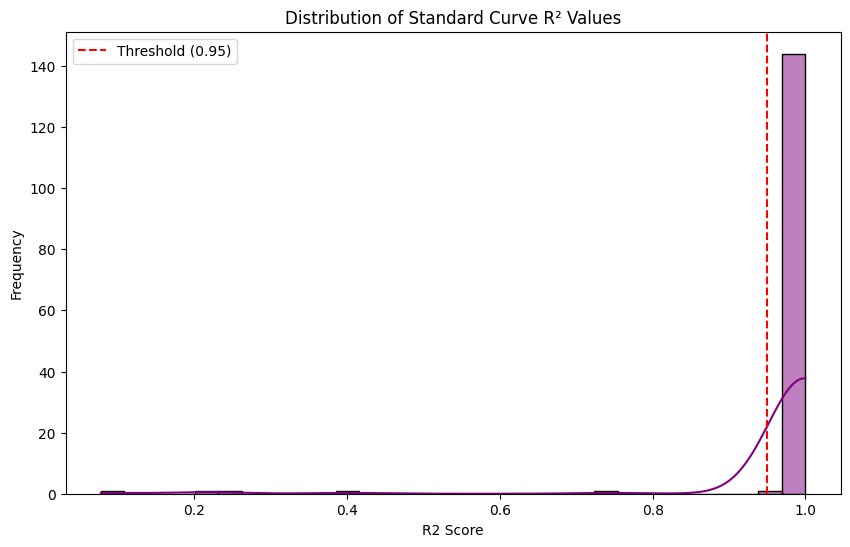

Total Standard Curves evaluated: 150
Average R² Score: 0.9762
Curves failing R² threshold (<0.95): 6

Chips associated with failed curves: ['B72604R8016', 'B72604R8030', 'B52501R8061', 'B72604R8038', 'B72604R8043', 'B72604R8006']
--------------------------------------------------------------------------------
FAILED CURVE DETAILS & PLOTS
--------------------------------------------------------------------------------
Chip ID: B72604R8016 | Curve UUID: csb562a | R²: 0.2006


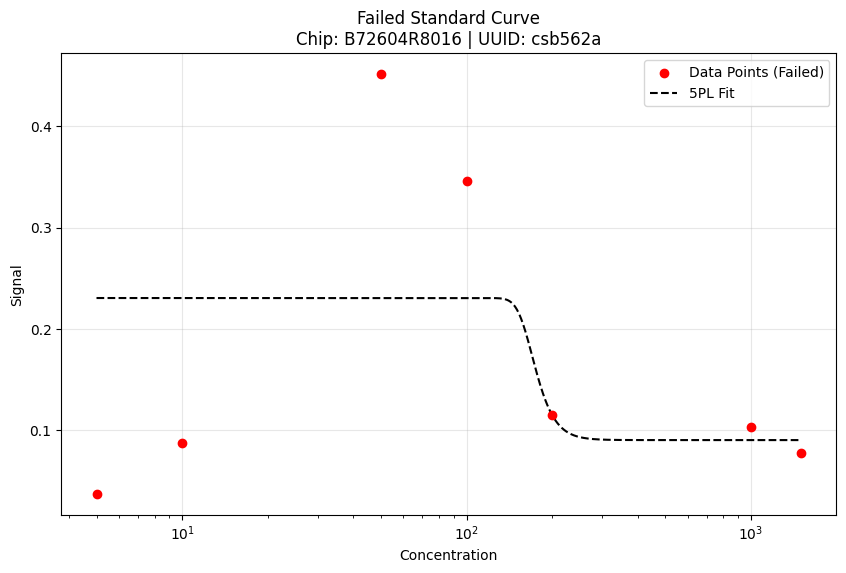

Chip ID: B72604R8030 | Curve UUID: cs36353 | R²: 0.4011


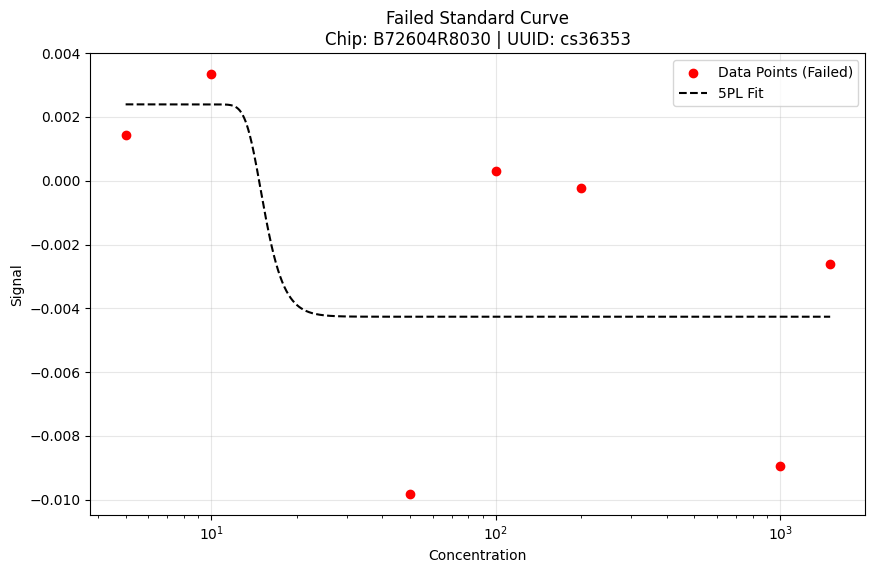

Chip ID: B52501R8061 | Curve UUID: cs84a80 | R²: 0.7446


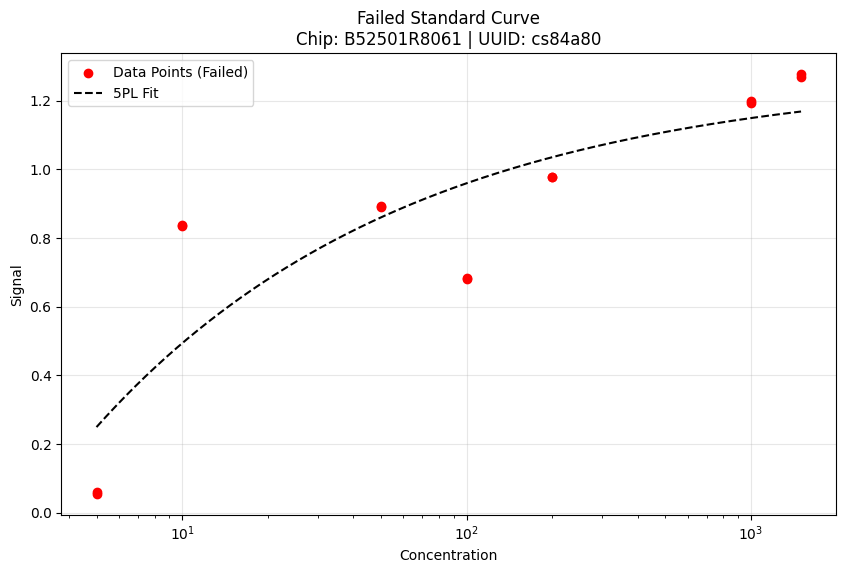

Chip ID: B72604R8038 | Curve UUID: cs2de12 | R²: 0.0775


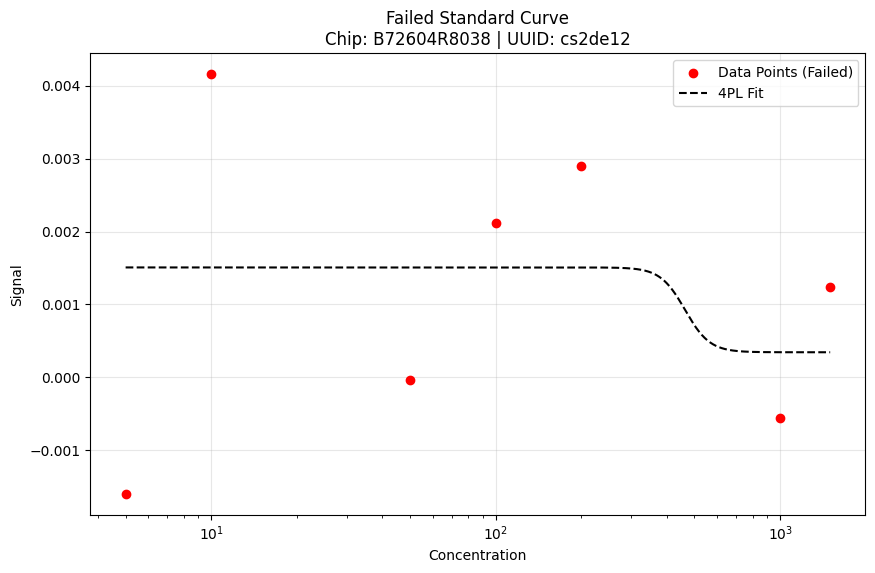

Chip ID: B72604R8043 | Curve UUID: cs419e1 | R²: 0.2325


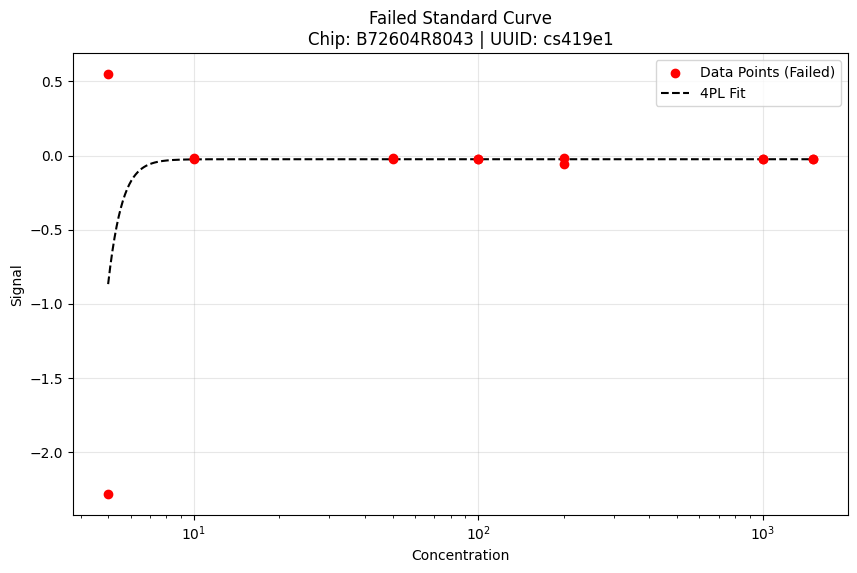

Chip ID: B72604R8006 | Curve UUID: cs5de64 | R²: 0.9463


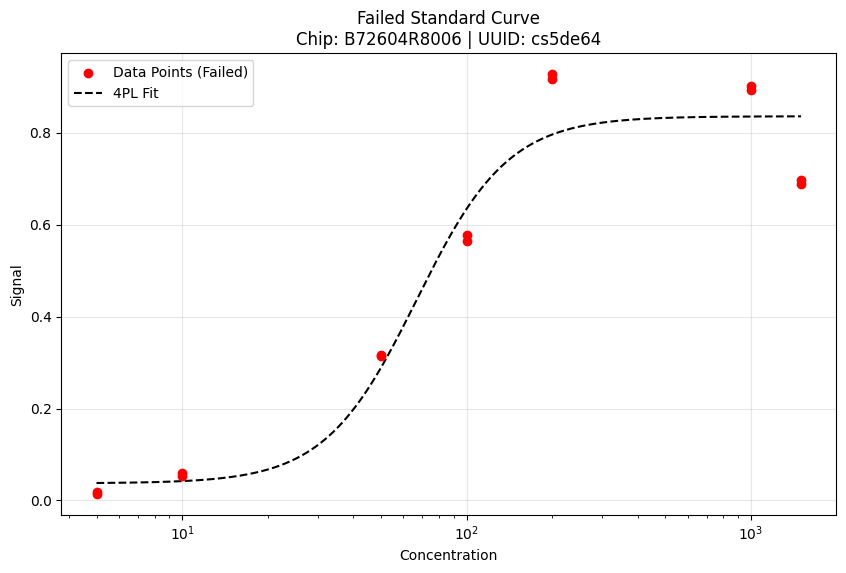

In [56]:
# Defines the minimum acceptable goodness-of-fit score threshold for standard curves
r2_threshold = 0.95

# Initialises a Matplotlib figure with specific dimensions
plt.figure(figsize=(10, 6))

# Plots a histogram with a kernel density estimate curve to show the distribution of R-squared values
sns.histplot(sc_metrics['r2'], bins=30, kde=True, color='purple')

# Adds a vertical dashed line indicating the minimum quality threshold
plt.axvline(r2_threshold, color='red', linestyle='--', label=f'Threshold ({r2_threshold})')

# Sets the title for the standard curve R-squared distribution plot
plt.title('Distribution of Standard Curve R² Values')

# Sets the x-axis label
plt.xlabel('R2 Score')

# Sets the y-axis label
plt.ylabel('Frequency')

# Adds a legend to the plot
plt.legend()

# Renders the distribution plot
plt.show()

# Filters the standard curve metrics to isolate curves falling below the quality threshold
failing_curves = sc_metrics[sc_metrics['r2'] < r2_threshold]

# Extracts a deduplicated list of chip identifiers associated with the failing curves
failing_chips = failing_curves.index.unique().tolist()

# Prints the total count of evaluated standard curves
print(f'Total Standard Curves evaluated: {len(sc_metrics)}')

# Prints the calculated average R-squared score across all standard curves
print(f"Average R² Score: {sc_metrics['r2'].mean():.4f}")

# Prints the total count of curves that failed the quality threshold
print(f'Curves failing R² threshold (<{r2_threshold}): {len(failing_curves)}')

# Evaluates whether any standard curves failed the quality check
if failing_chips:

    # Prints the list of chip identifiers linked to the failed curves
    print(f'\nChips associated with failed curves: {failing_chips}')

    # Prints a visual separator line
    print('-' * 80)

    # Prints a diagnostic header for the detailed curve analysis
    print('FAILED CURVE DETAILS & PLOTS')

    # Prints another visual separator line
    print('-' * 80)
    
    # Loops through each row in the filtered failing curves dataframe
    for chip_id, row in failing_curves.iterrows():

        # Prints the specific identifiers and R-squared score for the current failed curve
        print(f"Chip ID: {chip_id} | Curve UUID: {row['standard_curve_uuid']} | R²: {row['r2']:.4f}")
        
        # Converts the nested points list into a numpy array
        pts = np.array(row['points'])

        # Extracts the concentration and response arrays from the points data
        x_data, y_data = pts[:, 0], pts[:, 1]
        
        # Generates logarithmically spaced concentration points to plot the smooth curve fit
        xfit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 1000)
        
        # Evaluates whether the applied fit model is five-parameter logistic
        if row['fit_model'] == '5PL':

            # Calculates the predicted response curve using the five stored parameters
            yfit = five_pl(xfit, *row['parameters'])

        # Handles cases where the applied fit model is four-parameter logistic
        else:

            # Calculates the predicted response curve using the four stored parameters
            yfit = four_pl(xfit, *row['parameters'])
            
        # Initialises a Matplotlib figure for the failed curve diagnostic plot
        plt.figure(figsize=(10, 6))

        # Plots the raw measured coordinates as a red scatter plot
        plt.scatter(x_data, y_data, color='red', label='Data Points (Failed)', zorder=5)

        # Plots the calculated curve fit derived from the stored parameters as a dashed line
        plt.plot(xfit, yfit, color='black', linestyle='--', label=f"{row['fit_model']} Fit")
        
        # Sets the x-axis to a logarithmic scale for concentration
        plt.xscale('log')

        # Sets the title identifying the failed curve and chip
        plt.title(f"Failed Standard Curve\nChip: {chip_id} | UUID: {row['standard_curve_uuid']}")

        # Sets the x-axis label for concentration
        plt.xlabel('Concentration')

        # Sets the y-axis label for signal response
        plt.ylabel('Signal')

        # Adds a legend to the plot
        plt.legend()

        # Adds a subtle background grid to the plot
        plt.grid(True, alpha=0.3)

        # Renders the failed curve diagnostic plot
        plt.show()

## $\color{yellow}{\text{Cross-Stage (PEL + Immob) Analysis}}$

### $\color{red}{\text{Anomalies Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$ - MAIN

In [57]:
# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1, ensemble_anomalies_imp_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2, ensemble_anomalies_imp_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

In [58]:
# Compares PEL and immediate non-combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1, ensemble_anomalies_imp_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

# Compares PEL and immediate non-combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2, ensemble_anomalies_imp_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

In [59]:
# Compares PEL and immediate non-combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1, ensemble_anomalies_imp_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

# Compares PEL and immediate non-combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2, ensemble_anomalies_imp_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [60]:
# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

In [61]:
# Compares PEL and immediate non-combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

# Compares PEL and immediate non-combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

In [62]:
# Compares PEL and immediate non-combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

# Compares PEL and immediate non-combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [63]:
# Compares PEL and immediate combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], comb_results['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS]')

# Compares PEL and immediate combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], comb_results['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS]')

In [64]:
# Compares PEL and immediate combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], comb_results['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta]')

# Compares PEL and immediate combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], comb_results['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta]')

In [65]:
# Compares PEL and immediate combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], comb_results['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra]')

# Compares PEL and immediate combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], comb_results['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [66]:
# Compares PEL and five-second averaged non-combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_imp_results['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS]')

# Compares PEL and five-second averaged non-combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_imp_results['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS]')

In [67]:
# Compares PEL and five-second averaged non-combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_imp_results['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta]')

# Compares PEL and five-second averaged non-combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_imp_results['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta]')

In [68]:
# Compares PEL and five-second averaged non-combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_imp_results['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra]')

# Compares PEL and five-second averaged non-combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_imp_results['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [69]:
# Compares PEL and five-second averaged combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_comb_results['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS]')

# Compares PEL and five-second averaged combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_comb_results['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS]')

In [70]:
# Compares PEL and five-second averaged combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_comb_results['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta]')

# Compares PEL and five-second averaged combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_comb_results['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta]')

In [71]:
# Compares PEL and five-second averaged combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_comb_results['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1, immob_ensemble_ch1, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra]')

# Compares PEL and five-second averaged combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_comb_results['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2, immob_ensemble_ch2, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra]')

### $\color{red}{\text{Correlations Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [72]:
# Calculates cross-stage correlations for immediate non-combined absolute signals on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', title='Cross-Stage Corr: Imm (Non-Comb) [ABS]')

# Calculates cross-stage correlations for immediate non-combined absolute signals on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', title='Cross-Stage Corr: Imm (Non-Comb) [ABS]')

In [73]:
# Calculates cross-stage correlations for immediate non-combined stage changes on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta]')

# Calculates cross-stage correlations for immediate non-combined stage changes on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta]')

In [74]:
# Calculates cross-stage correlations for immediate non-combined kinetic features on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra]')

# Calculates cross-stage correlations for immediate non-combined kinetic features on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra]')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [75]:
# Calculates cross-stage correlations for immediate combined absolute signals on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['wide'], comb_results['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS]')

# Calculates cross-stage correlations for immediate combined absolute signals on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['wide'], comb_results['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS]')

In [76]:
# Calculates cross-stage correlations for immediate combined stage changes on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], comb_results['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta]')

# Calculates cross-stage correlations for immediate combined stage changes on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], comb_results['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta]')

In [77]:
# Calculates cross-stage correlations for immediate combined kinetic features on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], comb_results['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra]')

# Calculates cross-stage correlations for immediate combined kinetic features on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], comb_results['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [78]:
# Calculates cross-stage correlations for five-second averaged non-combined absolute signals on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_imp_results['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS]')

# Calculates cross-stage correlations for five-second averaged non-combined absolute signals on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_imp_results['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS]')

In [79]:
# Calculates cross-stage correlations for five-second averaged non-combined stage changes on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_imp_results['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta]')

# Calculates cross-stage correlations for five-second averaged non-combined stage changes on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_imp_results['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta]')

In [80]:
# Calculates cross-stage correlations for five-second averaged non-combined kinetic features on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_imp_results['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra]')

# Calculates cross-stage correlations for five-second averaged non-combined kinetic features on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_imp_results['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra]')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [81]:
# Calculates cross-stage correlations for five-second averaged combined absolute signals on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_comb_results['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS]')

# Calculates cross-stage correlations for five-second averaged combined absolute signals on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_comb_results['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS]')

In [82]:
# Calculates cross-stage correlations for five-second averaged combined stage changes on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_comb_results['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta]')

# Calculates cross-stage correlations for five-second averaged combined stage changes on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_comb_results['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta]')

In [83]:
# Calculates cross-stage correlations for five-second averaged combined kinetic features on Channel 1
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_comb_results['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra]')

# Calculates cross-stage correlations for five-second averaged combined kinetic features on Channel 2
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_comb_results['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra]')

## $\color{yellow}{\text{Cross-Stage (PEL + Immob) Analysis}}$ $\color{cyan}{\text{(PrG only)}}$

### $\color{red}{\text{Anomalies Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$ - MAIN

In [84]:
# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], imp_results['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_imp_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], imp_results['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, ensemble_anomalies_imp_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS]')

In [85]:
# Compares PEL and immediate non-combined stage changes using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], imp_results['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_imp_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

# Compares PEL and immediate non-combined stage changes using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], imp_results['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, ensemble_anomalies_imp_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta]')

In [86]:
# Compares PEL and immediate non-combined kinetic features using PCA for Channel 1
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], imp_results['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, ensemble_anomalies_imp_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

# Compares PEL and immediate non-combined kinetic features using PCA for Channel 2
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], imp_results['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, ensemble_anomalies_imp_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra]')

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [87]:
# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], imp_results_prg['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS] (PrG)')

# Compares PEL and immediate non-combined immobilisation signals using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], imp_results_prg['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [ABS] (PrG)')

In [88]:
# Compares PEL and immediate non-combined stage changes using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], imp_results_prg['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta] (PrG)')

# Compares PEL and immediate non-combined stage changes using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], imp_results_prg['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Delta] (PrG)')

In [89]:
# Compares PEL and immediate non-combined kinetic features using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], imp_results_prg['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra] (PrG)')

# Compares PEL and immediate non-combined kinetic features using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], imp_results_prg['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Non-Comb) [Intra] (PrG)')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [90]:
# Compares PEL and immediate combined immobilisation signals using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], comb_results_prg['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS] (PrG)')

# Compares PEL and immediate combined immobilisation signals using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], comb_results_prg['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [ABS] (PrG)')

In [91]:
# Compares PEL and immediate combined stage changes using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], comb_results_prg['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta] (PrG)')

# Compares PEL and immediate combined stage changes using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], comb_results_prg['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Delta] (PrG)')

In [92]:
# Compares PEL and immediate combined kinetic features using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], comb_results_prg['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra] (PrG)')

# Compares PEL and immediate combined kinetic features using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], comb_results_prg['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: Imm (Comb) [Intra] (PrG)')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [93]:
# Compares PEL and five-second averaged non-combined immobilisation signals using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_imp_results_prg['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS] (PrG)')

# Compares PEL and five-second averaged non-combined immobilisation signals using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_imp_results_prg['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Combined) [ABS] (PrG)')

In [94]:
# Compares PEL and five-second averaged non-combined stage changes using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_imp_results_prg['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta] (PrG)')

# Compares PEL and five-second averaged non-combined stage changes using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_imp_results_prg['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Delta] (PrG)')

In [95]:
# Compares PEL and five-second averaged non-combined kinetic features using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_imp_results_prg['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra] (PrG)')

# Compares PEL and five-second averaged non-combined kinetic features using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_imp_results_prg['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Non-Comb) [Intra] (PrG)')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [96]:
# Compares PEL and five-second averaged combined immobilisation signals using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['wide'], avg_comb_results_prg['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS] (PrG)')

# Compares PEL and five-second averaged combined immobilisation signals using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['wide'], avg_comb_results_prg['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [ABS] (PrG)')

In [97]:
# Compares PEL and five-second averaged combined stage changes using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['change_wide'], avg_comb_results_prg['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta] (PrG)')

# Compares PEL and five-second averaged combined stage changes using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['change_wide'], avg_comb_results_prg['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Delta] (PrG)')

In [98]:
# Compares PEL and five-second averaged combined kinetic features using PCA for Channel 1 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch1']['intra_wide'], avg_comb_results_prg['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', ensemble_anomalies_pel_ch1_prg, immob_ensemble_ch1_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra] (PrG)')

# Compares PEL and five-second averaged combined kinetic features using PCA for Channel 2 (PrG Filtered)
analyse_cross_stage_split(pel_results['quad_ch2']['intra_wide'], avg_comb_results_prg['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', ensemble_anomalies_pel_ch2_prg, immob_ensemble_ch2_prg, sc_metrics, title='Cross-Stage PCA: 5s Average (Combined) [Intra] (PrG)')

### $\color{red}{\text{Correlations Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [99]:
# Calculates cross-stage correlations for immediate non-combined absolute signals on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['wide'], imp_results_prg['channel1']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [ABS] (PrG)')

# Calculates cross-stage correlations for immediate non-combined absolute signals on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['wide'], imp_results_prg['channel2']['wide'], 'Immediate (Non-Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [ABS] (PrG)')

In [100]:
# Calculates cross-stage correlations for immediate non-combined stage changes on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], imp_results_prg['channel1']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta] (PrG)')

# Calculates cross-stage correlations for immediate non-combined stage changes on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], imp_results_prg['channel2']['change_wide'], 'Immediate (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Delta] (PrG)')

In [101]:
# Calculates cross-stage correlations for immediate non-combined kinetic features on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], imp_results_prg['channel1']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra] (PrG)')

# Calculates cross-stage correlations for immediate non-combined kinetic features on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], imp_results_prg['channel2']['intra_wide'], 'Immediate (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Non-Comb) [Intra] (PrG)')

#### $\color{lime}{\text{Immediate (Combined)}}$

In [102]:
# Calculates cross-stage correlations for immediate combined absolute signals on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['wide'], comb_results_prg['channel1']['wide'], 'Immediate (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS] (PrG)')

# Calculates cross-stage correlations for immediate combined absolute signals on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['wide'], comb_results_prg['channel2']['wide'], 'Immediate (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [ABS] (PrG)')

In [103]:
# Calculates cross-stage correlations for immediate combined stage changes on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], comb_results_prg['channel1']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta] (PrG)')

# Calculates cross-stage correlations for immediate combined stage changes on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], comb_results_prg['channel2']['change_wide'], 'Immediate (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Delta] (PrG)')

In [104]:
# Calculates cross-stage correlations for immediate combined kinetic features on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], comb_results_prg['channel1']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra] (PrG)')

# Calculates cross-stage correlations for immediate combined kinetic features on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], comb_results_prg['channel2']['intra_wide'], 'Immediate (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: Imm (Comb) [Intra] (PrG)')

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [105]:
# Calculates cross-stage correlations for five-second averaged non-combined absolute signals on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_imp_results_prg['channel1']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS] (PrG)')

# Calculates cross-stage correlations for five-second averaged non-combined absolute signals on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_imp_results_prg['channel2']['wide'], '5s Average (Non-Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Combined) [ABS] (PrG)')

In [106]:
# Calculates cross-stage correlations for five-second averaged non-combined stage changes on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_imp_results_prg['channel1']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta] (PrG)')

# Calculates cross-stage correlations for five-second averaged non-combined stage changes on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_imp_results_prg['channel2']['change_wide'], '5s Average (Non-Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Delta] (PrG)')

In [107]:
# Calculates cross-stage correlations for five-second averaged non-combined kinetic features on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_imp_results_prg['channel1']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra] (PrG)')

# Calculates cross-stage correlations for five-second averaged non-combined kinetic features on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_imp_results_prg['channel2']['intra_wide'], '5s Average (Non-Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Non-Comb) [Intra] (PrG)')

#### $\color{lime}{\text{5s Average (Combined)}}$

In [108]:
# Calculates cross-stage correlations for five-second averaged combined absolute signals on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['wide'], avg_comb_results_prg['channel1']['wide'], '5s Average (Combined) [ABS]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS] (PrG)')

# Calculates cross-stage correlations for five-second averaged combined absolute signals on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['wide'], avg_comb_results_prg['channel2']['wide'], '5s Average (Combined) [ABS]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [ABS] (PrG)')

In [109]:
# Calculates cross-stage correlations for five-second averaged combined stage changes on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['change_wide'], avg_comb_results_prg['channel1']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta] (PrG)')

# Calculates cross-stage correlations for five-second averaged combined stage changes on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['change_wide'], avg_comb_results_prg['channel2']['change_wide'], '5s Average (Combined) [Delta]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Delta] (PrG)')

In [110]:
# Calculates cross-stage correlations for five-second averaged combined kinetic features on Channel 1 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch1']['intra_wide'], avg_comb_results_prg['channel1']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 1', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra] (PrG)')

# Calculates cross-stage correlations for five-second averaged combined kinetic features on Channel 2 (PrG Filtered)
cross_stage_correlations(pel_results['quad_ch2']['intra_wide'], avg_comb_results_prg['channel2']['intra_wide'], '5s Average (Combined) [Intra]', 'Channel 2', sc_metrics, title='Cross-Stage Corr: 5s Average (Combined) [Intra] (PrG)')

## $\color{yellow}{\text{Interactive Stage Comparison Dashboards}}$

### $\color{red}{\text{Setup}}$

In [111]:
# Creates a copy of the standard curve metrics dataframe to preserve the original data
sc_copy = sc_metrics.copy()

# Casts the column names to strings to ensure consistent indexing and merging
sc_copy.columns = sc_copy.columns.astype(str)

# Extracts a list of exclusively numeric column names suitable for cross-stage comparison
numeric_cols = sc_copy.select_dtypes(include='number').columns.tolist()

# Evaluates whether the datetime column is present in the copied dataframe
if 'datetime' in sc_copy.columns:

    # Filters the dataframe to include the datetime column alongside the numeric metrics
    sc_copy = sc_copy[['datetime'] + numeric_cols]

# Handles cases where the datetime column is missing
else:

    # Filters the dataframe to include only the numeric metrics
    sc_copy = sc_copy[numeric_cols]

# Isolates the chronologically first standard curve record per chip, dropping the datetime column afterward
sc_first = sc_copy.sort_values('datetime').groupby(sc_copy.index, sort=False).first().drop(columns='datetime')

In [112]:
# Constructs a nested catalog dictionary aggregating analysis datasets for the interactive dashboard
master_data_catalog = {

    # Maps absolute-signal datasets across stages and channels
    'Absolute': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['wide'], 'Channel 2': pel_results['quad_ch2']['wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['wide'], 'Channel 2': imp_results['channel2']['wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['wide'], 'Channel 2': comb_results['channel2']['wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['wide'], 'Channel 2': avg_imp_results['channel2']['wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['wide'], 'Channel 2': avg_comb_results['channel2']['wide']},
        'Standard Curve': {'Channel 1': sc_first} 
    },

    # Maps stage-to-stage signal-change datasets across stages and channels
    'Stage Delta': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['change_wide'], 'Channel 2': pel_results['quad_ch2']['change_wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['change_wide'], 'Channel 2': imp_results['channel2']['change_wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['change_wide'], 'Channel 2': comb_results['channel2']['change_wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['change_wide'], 'Channel 2': avg_imp_results['channel2']['change_wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['change_wide'], 'Channel 2': avg_comb_results['channel2']['change_wide']},
        'Standard Curve': {'Channel 1': sc_first}
    },
    
    # Maps intra-stage kinetic feature datasets across stages and channels
    'Intra-stage Kinetics': {
        'PEL': {'Channel 1': pel_results['quad_ch1']['intra_wide'], 'Channel 2': pel_results['quad_ch2']['intra_wide']},
        'Immob (Imm, Non-Comb)': {'Channel 1': imp_results['channel1']['intra_wide'], 'Channel 2': imp_results['channel2']['intra_wide']},
        'Immob (Imm, Comb)': {'Channel 1': comb_results['channel1']['intra_wide'], 'Channel 2': comb_results['channel2']['intra_wide']},
        'Immob (5s, Non-Comb)': {'Channel 1': avg_imp_results['channel1']['intra_wide'], 'Channel 2': avg_imp_results['channel2']['intra_wide']},
        'Immob (5s, Comb)': {'Channel 1': avg_comb_results['channel1']['intra_wide'], 'Channel 2': avg_comb_results['channel2']['intra_wide']},
        'Standard Curve': {'Channel 1': sc_first}
    }
}

In [113]:
# Saves interactive dashboard data
# Opens a binary file stream to securely export the assembled dashboard catalog
with open('dashboard_catalog.pkl', 'wb') as f:

    # Serialises and writes the master catalog dictionary to the local disk
    pickle.dump(master_data_catalog, f)

### $\color{red}{\text{Display}}$

In [114]:
# Launches the interactive data exploration dashboard using the assembled master catalog
create_interactive_dashboard(master_data_catalog)

HTML(value="<h3 style='margin-bottom:0px; color:#0000FF;'>Master Chip Comparison Dashboard</h3>")

Output()

Output()

# $\color{orange}{\text{Overall Summary}}$

---

## $\color{yellow}{\text{Setup}}$

In [115]:
# Defines the configuration mapping mapping analysis splits to their respective ensemble evaluations
section_config = {
    
    # Extracts the ensemble section specifically for PEL Channel 1
    'PEL Ensemble (Ch1)': prepare_ensemble_section(pel_events_norm, pel_changes, pel_intra, 'quad_ch1', 'quad_ch1_change'),

    # Extracts the ensemble section specifically for PEL Channel 2
    'PEL Ensemble (Ch2)': prepare_ensemble_section(pel_events_norm, pel_changes, pel_intra, 'quad_ch2', 'quad_ch2_change'),

    # Extracts the ensemble section for immediate non-combined immobilisation on Channel 1
    'Immob Immediate Non-Comb Ensemble (Ch1)': prepare_ensemble_section(imp_norm, imp_changes, imp_intra, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for immediate non-combined immobilisation on Channel 2
    'Immob Immediate Non-Comb Ensemble (Ch2)': prepare_ensemble_section(imp_norm, imp_changes, imp_intra, 'channel2', 'channel2_change')
}
'''
    # Extracts the ensemble section for immediate combined immobilisation on Channel 1
    'Immob Immediate Comb Ensemble (Ch1)': prepare_ensemble_section(comb_norm, comb_changes, comb_intra, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for immediate combined immobilisation on Channel 2
    'Immob Immediate Comb Ensemble (Ch2)': prepare_ensemble_section(comb_norm, comb_changes, comb_intra, 'channel2', 'channel2_change'),

    # Extracts the ensemble section for averaged non-combined immobilisation on Channel 1
    'Immob 5s Avg Non-Comb Ensemble (Ch1)': prepare_ensemble_section(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for averaged non-combined immobilisation on Channel 2
    'Immob 5s Avg Non-Comb Ensemble (Ch2)': prepare_ensemble_section(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'channel2', 'channel2_change'),

    # Extracts the ensemble section for averaged combined immobilisation on Channel 1
    'Immob 5s Avg Comb Ensemble (Ch1)': prepare_ensemble_section(avg_comb_norm, avg_comb_changes, avg_comb_intra, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for averaged combined immobilisation on Channel 2
    'Immob 5s Avg Comb Ensemble (Ch2)': prepare_ensemble_section(avg_comb_norm, avg_comb_changes, avg_comb_intra, 'channel2', 'channel2_change')
}'''

"\n    # Extracts the ensemble section for immediate combined immobilisation on Channel 1\n    'Immob Immediate Comb Ensemble (Ch1)': prepare_ensemble_section(comb_norm, comb_changes, comb_intra, 'channel1', 'channel1_change'),\n\n    # Extracts the ensemble section for immediate combined immobilisation on Channel 2\n    'Immob Immediate Comb Ensemble (Ch2)': prepare_ensemble_section(comb_norm, comb_changes, comb_intra, 'channel2', 'channel2_change'),\n\n    # Extracts the ensemble section for averaged non-combined immobilisation on Channel 1\n    'Immob 5s Avg Non-Comb Ensemble (Ch1)': prepare_ensemble_section(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'channel1', 'channel1_change'),\n\n    # Extracts the ensemble section for averaged non-combined immobilisation on Channel 2\n    'Immob 5s Avg Non-Comb Ensemble (Ch2)': prepare_ensemble_section(avg_imp_norm, avg_imp_changes, avg_imp_intra, 'channel2', 'channel2_change'),\n\n    # Extracts the ensemble section for averaged combined i

In [116]:
# Initialises a tracking set using the list of chips that failed standard curve checks
all_at_risk_chips = set(failing_chips)

# Loops through the generated configuration dictionary to extract mapped outliers
for _, outliers in section_config.values():

    # Updates the overall tracking set with the anomalies extracted from each analysis split
    all_at_risk_chips.update(outliers)

In [117]:
# Extracts and suffixes the underlying absolute dataframe for PEL Channel 1
pel_1 = section_config['PEL Ensemble (Ch1)'][0]['Absolute'].copy().add_suffix('_PEL_Ch1')

# Extracts and suffixes the underlying absolute dataframe for PEL Channel 2
pel_2 = section_config['PEL Ensemble (Ch2)'][0]['Absolute'].copy().add_suffix('_PEL_Ch2')

# Extracts and suffixes the underlying absolute dataframe for Immobilisation Channel 1
immob_1 = section_config['Immob Immediate Non-Comb Ensemble (Ch1)'][0]['Absolute'].copy().add_suffix('_Immob_Ch1')

# Extracts and suffixes the underlying absolute dataframe for Immobilisation Channel 2
immob_2 = section_config['Immob Immediate Non-Comb Ensemble (Ch2)'][0]['Absolute'].copy().add_suffix('_Immob_Ch2')

# Concatenates the extracted absolute dataframes into a master structure using an inner join
master_df = pd.concat([pel_1, pel_2, immob_1, immob_2], axis=1, join='inner')

# Prints the total number of perfectly aligned rows in the generated master dataframe
print(len(master_df))

32


## $\color{yellow}{\text{Chips That May Fail}}$

In [118]:
# Executes the overall diagnostic summary, compiling anomaly drivers for every flagged chip
generate_at_risk_summary(master_df, sc_metrics, tables['standard_curves'], all_at_risk_chips, section_config, all_incomplete_chips, 'At-Risk Chips & Anomaly Drivers')

# $\color{orange}{\text{Overall Summary}}$ $\color{cyan}{\text{(PrG only)}}$

---

## $\color{yellow}{\text{Setup}}$

In [119]:
# Filter immediate non-combined immobilisation dataframes for PrG stages
imp_norm_prg = imp_norm[imp_norm['stage'].str.startswith('PrG', na=False)]
imp_changes_prg = imp_changes[imp_changes['stage'].str.startswith('PrG', na=False)]
imp_intra_prg = imp_intra[imp_intra['stage'].str.startswith('PrG', na=False)]

# Filter immediate combined immobilisation dataframes for PrG stages
comb_norm_prg = comb_norm[comb_norm['stage'].str.startswith('PrG', na=False)]
comb_changes_prg = comb_changes[comb_changes['stage'].str.startswith('PrG', na=False)]
comb_intra_prg = comb_intra[comb_intra['stage'].str.startswith('PrG', na=False)]

# Filter five-second averaged non-combined immobilisation dataframes for PrG stages
avg_imp_norm_prg = avg_imp_norm[avg_imp_norm['stage'].str.startswith('PrG', na=False)]
avg_imp_changes_prg = avg_imp_changes[avg_imp_changes['stage'].str.startswith('PrG', na=False)]
avg_imp_intra_prg = avg_imp_intra[avg_imp_intra['stage'].str.startswith('PrG', na=False)]

# Filter five-second averaged combined immobilisation dataframes for PrG stages
avg_comb_norm_prg = avg_comb_norm[avg_comb_norm['stage'].str.startswith('PrG', na=False)]
avg_comb_changes_prg = avg_comb_changes[avg_comb_changes['stage'].str.startswith('PrG', na=False)]
avg_comb_intra_prg = avg_comb_intra[avg_comb_intra['stage'].str.startswith('PrG', na=False)]

In [120]:
# Defines the configuration mapping mapping PrG-filtered analysis splits to their respective ensemble evaluations
section_config_prg = {
    
    # Extracts the ensemble section specifically for PEL Channel 1 (inherently includes PrG)
    'PEL Ensemble (Ch1)': prepare_ensemble_section(pel_events_norm, pel_changes, pel_intra, 'quad_ch1', 'quad_ch1_change'),

    # Extracts the ensemble section specifically for PEL Channel 2 (inherently includes PrG)
    'PEL Ensemble (Ch2)': prepare_ensemble_section(pel_events_norm, pel_changes, pel_intra, 'quad_ch2', 'quad_ch2_change'),

    # Extracts the ensemble section for PrG-filtered immediate non-combined immobilisation on Channel 1
    'Immob Immediate Non-Comb Ensemble (Ch1)': prepare_ensemble_section(imp_norm_prg, imp_changes_prg, imp_intra_prg, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for PrG-filtered immediate non-combined immobilisation on Channel 2
    'Immob Immediate Non-Comb Ensemble (Ch2)': prepare_ensemble_section(imp_norm_prg, imp_changes_prg, imp_intra_prg, 'channel2', 'channel2_change'),
}
''' # Extracts the ensemble section for PrG-filtered immediate combined immobilisation on Channel 1
    'Immob Immediate Comb Ensemble (Ch1)': prepare_ensemble_section(comb_norm_prg, comb_changes_prg, comb_intra_prg, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for PrG-filtered immediate combined immobilisation on Channel 2
    'Immob Immediate Comb Ensemble (Ch2)': prepare_ensemble_section(comb_norm_prg, comb_changes_prg, comb_intra_prg, 'channel2', 'channel2_change'),

    # Extracts the ensemble section for PrG-filtered averaged non-combined immobilisation on Channel 1
    'Immob 5s Avg Non-Comb Ensemble (Ch1)': prepare_ensemble_section(avg_imp_norm_prg, avg_imp_changes_prg, avg_imp_intra_prg, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for PrG-filtered averaged non-combined immobilisation on Channel 2
    'Immob 5s Avg Non-Comb Ensemble (Ch2)': prepare_ensemble_section(avg_imp_norm_prg, avg_imp_changes_prg, avg_imp_intra_prg, 'channel2', 'channel2_change'),

    # Extracts the ensemble section for PrG-filtered averaged combined immobilisation on Channel 1
    'Immob 5s Avg Comb Ensemble (Ch1)': prepare_ensemble_section(avg_comb_norm_prg, avg_comb_changes_prg, avg_comb_intra_prg, 'channel1', 'channel1_change'),

    # Extracts the ensemble section for PrG-filtered averaged combined immobilisation on Channel 2
    'Immob 5s Avg Comb Ensemble (Ch2)': prepare_ensemble_section(avg_comb_norm_prg, avg_comb_changes_prg, avg_comb_intra_prg, 'channel2', 'channel2_change')
}'''

" # Extracts the ensemble section for PrG-filtered immediate combined immobilisation on Channel 1\n    'Immob Immediate Comb Ensemble (Ch1)': prepare_ensemble_section(comb_norm_prg, comb_changes_prg, comb_intra_prg, 'channel1', 'channel1_change'),\n\n    # Extracts the ensemble section for PrG-filtered immediate combined immobilisation on Channel 2\n    'Immob Immediate Comb Ensemble (Ch2)': prepare_ensemble_section(comb_norm_prg, comb_changes_prg, comb_intra_prg, 'channel2', 'channel2_change'),\n\n    # Extracts the ensemble section for PrG-filtered averaged non-combined immobilisation on Channel 1\n    'Immob 5s Avg Non-Comb Ensemble (Ch1)': prepare_ensemble_section(avg_imp_norm_prg, avg_imp_changes_prg, avg_imp_intra_prg, 'channel1', 'channel1_change'),\n\n    # Extracts the ensemble section for PrG-filtered averaged non-combined immobilisation on Channel 2\n    'Immob 5s Avg Non-Comb Ensemble (Ch2)': prepare_ensemble_section(avg_imp_norm_prg, avg_imp_changes_prg, avg_imp_intra_prg,

In [121]:
# Initialises a tracking set using the list of chips that failed standard curve checks
all_at_risk_chips_prg = set(failing_chips)

# Loops through the generated configuration dictionary to extract mapped outliers
for _, outliers in section_config_prg.values():

    # Updates the overall tracking set with the anomalies extracted from each PrG-filtered analysis split
    all_at_risk_chips_prg.update(outliers)

In [122]:
# Extracts and suffixes the underlying absolute dataframe for PEL Channel 1
pel_1_prg = section_config_prg['PEL Ensemble (Ch1)'][0]['Absolute'].copy().add_suffix('_PEL_Ch1')

# Extracts and suffixes the underlying absolute dataframe for PEL Channel 2
pel_2_prg = section_config_prg['PEL Ensemble (Ch2)'][0]['Absolute'].copy().add_suffix('_PEL_Ch2')

# Extracts and suffixes the underlying absolute dataframe for PrG-filtered Immobilisation Channel 1
immob_1_prg = section_config_prg['Immob Immediate Non-Comb Ensemble (Ch1)'][0]['Absolute'].copy().add_suffix('_Immob_Ch1')

# Extracts and suffixes the underlying absolute dataframe for PrG-filtered Immobilisation Channel 2
immob_2_prg = section_config_prg['Immob Immediate Non-Comb Ensemble (Ch2)'][0]['Absolute'].copy().add_suffix('_Immob_Ch2')

# Concatenates the extracted absolute dataframes into a master structure using an inner join
master_df_prg = pd.concat([pel_1_prg, pel_2_prg, immob_1_prg, immob_2_prg], axis=1, join='inner')

# Prints the total number of perfectly aligned rows in the generated master dataframe
print(len(master_df_prg))

32


## $\color{yellow}{\text{Chips That May Fail}}$

In [123]:
# Executes the overall diagnostic summary, compiling anomaly drivers for every flagged chip using PrG-filtered data
generate_at_risk_summary(master_df_prg, sc_metrics, tables['standard_curves'], all_at_risk_chips_prg, section_config_prg, all_incomplete_chips, 'At-Risk Chips & Anomaly Drivers (PrG Only)')

# $\color{orange}{\text{Standard Curve Extra Data (Single Chip)}}$

---

## $\color{yellow}{\text{Getting SC Data}}$

In [124]:
# Assigns the target directory containing the exported standard curve CSV files
base_dir = 'Standard Curve Files'

# Initialises an empty nested dictionary to logically categorise extracted files by their source folder
files = {}

# Loops through each item located inside the specified base directory
for folder in os.listdir(base_dir):

    # Constructs the absolute path for the current item
    folder_path = os.path.join(base_dir, folder)

    # Evaluates whether the constructed path points to a valid directory
    if os.path.isdir(folder_path):

        # Initialises an empty dictionary under the folder name key
        files[folder] = {}

        # Loops through each file found inside the validated export folder
        for file in os.listdir(folder_path):

            # Constructs the absolute path for the specific file
            file_path = os.path.join(folder_path, file)

            # Evaluates whether the current file is a CSV format target
            if file.endswith('.csv'):
                
                # Strips the file extension to generate a clean dictionary key
                file_name = os.path.splitext(file)[0]

                # Reads the targeted CSV file into a pandas dataframe
                df = pd.read_csv(file_path)

                # Evaluates whether the filename indicates the presence of raw sensorgram data
                if 'sensorgram' in file_name.lower():

                    # Defines the strict column schema required for sensorgram arrays
                    expected = ['time', 'channel1', 'channel2']

                    # Evaluates whether the loaded headers match the strictly defined schema
                    if list(df.columns[:2]) != expected:

                        # Reloads the CSV file specifying that no headers are present in the raw data
                        df = pd.read_csv(file_path, header=None)

                        # Overwrites the dataframe columns with the strictly defined schema
                        df.columns = expected

                # Maps the fully processed dataframe to its corresponding file key
                files[folder][file_name] = df

## $\color{yellow}{\text{Basic Analysis}}$

In [125]:
# Executes the baseline shift and normalisation workflow on the parsed files
files = analyse_standard_curves_extra(files)

Baseline flags already exist in folder 2026-04-13. Skipping entire folder.
Baseline flags already exist in folder 2026-04-15. Skipping entire folder.
Baseline flags already exist in folder 2026-04-16. Skipping entire folder.

Evaluating Folder: 2026-04-13

--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Evaluating Folder: 2026-04-15

--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Evaluating Folder: 2026-04-16

--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


## $\color{yellow}{\text{Binding Kinetics}}$

In [126]:
# Executes the advanced binding kinetics pipeline using the processed file database
kinetics_results = run_binding_kinetics_analysis(files)


Overall Kinetics Distributions



Kinetics Analysis: 2026-04-13



--- Chip ID: B52501R8242 | Measurement ID: csa5eb7 ---



--- Chip ID: B52501R8242 | Measurement ID: csda3af ---



Kinetics Analysis: 2026-04-15



--- Chip ID: B52501R8242 | Measurement ID: cs5dbc5 ---



Kinetics Analysis: 2026-04-16



--- Chip ID: B52501R8242 | Measurement ID: cs3142c ---


# $\color{orange}{\text{Standard Curve Extra Data (Multi-Chip)}}$

---

## $\color{yellow}{\text{Getting SC Data}}$

In [127]:
# Assigns the secondary target directory containing exported standard curve CSV files
base_dir2 = 'SCs'

# Initialises an empty nested dictionary to logically categorise extracted files by their source folder
files2 = {}

# Loops through each item located inside the specified base directory
for folder in os.listdir(base_dir2):

    # Constructs the absolute path for the current item
    folder_path = os.path.join(base_dir2, folder)

    # Evaluates whether the constructed path points to a valid directory
    if os.path.isdir(folder_path):

        # Initialises an empty dictionary under the folder name key
        files2[folder] = {}

        # Loops through each file found inside the validated export folder
        for file in os.listdir(folder_path):

            # Constructs the absolute path for the specific file
            file_path = os.path.join(folder_path, file)

            # Evaluates whether the current file is a CSV format target
            if file.endswith('.csv'):
                
                # Strips the file extension to generate a clean dictionary key
                file_name = os.path.splitext(file)[0]

                # Reads the targeted CSV file into a pandas dataframe
                df = pd.read_csv(file_path)

                # Evaluates whether the filename indicates the presence of raw sensorgram data
                if 'sensorgram' in file_name.lower():

                    # Defines the strict column schema required for sensorgram arrays
                    expected = ['time', 'channel1', 'channel2']

                    # Evaluates whether the loaded headers match the strictly defined schema
                    if list(df.columns[:2]) != expected:

                        # Reloads the CSV file specifying that no headers are present in the raw data
                        df = pd.read_csv(file_path, header=None)

                        # Overwrites the dataframe columns with the strictly defined schema
                        df.columns = expected

                # Maps the fully processed dataframe to its corresponding file key
                files2[folder][file_name] = df

## $\color{yellow}{\text{Basic Analysis}}$

In [128]:
# Executes the baseline shift and normalisation workflow on the parsed files
files2 = analyse_standard_curves_extra(files2, base_dir2)

Baseline flags already exist in folder B72604R8008. Skipping entire folder.
Baseline flags already exist in folder B72604R8027. Skipping entire folder.
Baseline flags already exist in folder B72604R8029. Skipping entire folder.
Baseline flags already exist in folder B72604R8037. Skipping entire folder.
Baseline flags already exist in folder B72604R8038. Skipping entire folder.
Baseline flags already exist in folder B72604R8042. Skipping entire folder.
Baseline flags already exist in folder B72604R8043. Skipping entire folder.
Baseline flags already exist in folder B72604R8047. Skipping entire folder.
Baseline flags already exist in folder B72604R8053. Skipping entire folder.
Baseline flags already exist in folder B72604R8055. Skipping entire folder.
Baseline flags already exist in folder B72604R81032. Skipping entire folder.
Baseline flags already exist in folder B72604R8110. Skipping entire folder.
Baseline flags already exist in folder B72604R8112. Skipping entire folder.
Baseline fl


Evaluating Folder: B72604R8027

--- Chip ID: B72604R8027 | Measurement ID: csd2936 ---



Evaluating Folder: B72604R8029

--- Chip ID: B72604R8029 | Measurement ID: cs1d4e9 ---



Evaluating Folder: B72604R8037

--- Chip ID: B72604R8037 | Measurement ID: csa61e0 ---



Evaluating Folder: B72604R8038

--- Chip ID: B72604R8038 | Measurement ID: csfa2c3 ---


...


Evaluating Folder: B72604R81032

--- Chip ID: B72604R8032 | Measurement ID: cs4f228 ---



Evaluating Folder: B72604R8110

--- Chip ID: B72604R8110 | Measurement ID: cs27f71 ---



--- Chip ID: B72604R8110 | Measurement ID: cs4fc25 ---



Evaluating Folder: B72604R8112

--- Chip ID: B72604R8112 | Measurement ID: cs9bb12 ---



Evaluating Folder: B72604R8138

--- Chip ID: B72604R8138 | Measurement ID: cse0631 ---


## $\color{yellow}{\text{Binding Kinetics}}$

In [129]:
# Executes the advanced binding kinetics pipeline using the processed file database
kinetics_results = run_binding_kinetics_analysis(files2)


Overall Kinetics Distributions



Kinetics Analysis: B72604R8008



--- Chip ID: B72604R8008 | Measurement ID: cs38715 ---



Kinetics Analysis: B72604R8027



--- Chip ID: B72604R8027 | Measurement ID: csd2936 ---


...


--- Chip ID: B72604R8110 | Measurement ID: cs4fc25 ---



Kinetics Analysis: B72604R8112



--- Chip ID: B72604R8112 | Measurement ID: cs9bb12 ---



Kinetics Analysis: B72604R8138



--- Chip ID: B72604R8138 | Measurement ID: cse0631 ---


# $\color{cyan}{\text{Run Check}}$

In [130]:
# Prints a standard output confirmation confirming successful completion of the notebook operations
print('run completed')

run completed


## $\color{yellow}{\text{Seperate}}$

In [131]:
# Initialises tracking variables for preliminary PEL sensorgram channel order comparisons
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through the parsed sensorgram dictionary to perform raw signal evaluations
for file_name, file_data in bucket_data['Sensorgram'].items():

    # Evaluates whether the primary channel's first recorded value is lower than the secondary's
    if file_data['quad_ch1'].iloc[0] < file_data['quad_ch2'].iloc[0]:

        # Increments the count for lower primary channels
        total_ch1_less += 1

    # Evaluates whether the primary channel's first recorded value is higher than the secondary's
    elif file_data['quad_ch1'].iloc[0] > file_data['quad_ch2'].iloc[0]:

        # Increments the count for higher primary channels
        total_ch2_less += 1

    # Handles edge cases where both channels start perfectly equal
    else:

        # Increments the count for equivalent channels
        total_equal += 1

# Prints the final distribution of initial channel states for PEL sensorgrams
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  191
Ch1 > Ch2:  3
Ch1 = Ch2:  9


In [132]:
# Initialises tracking variables for preliminary RefPoly4 channel order comparisons
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

# Loops through the parsed RefPoly4 dictionary to perform raw signal evaluations
for file_name, file_data in bucket_data['RefPoly4'].items():

    # Evaluates whether the primary channel's first recorded value is lower than the secondary's
    if file_data['channel1'].iloc[0] < file_data['channel2'].iloc[0]:

        # Increments the count for lower primary channels
        total_ch1_less += 1

    # Evaluates whether the primary channel's first recorded value is higher than the secondary's
    elif file_data['channel1'].iloc[0] > file_data['channel2'].iloc[0]:

        # Increments the count for higher primary channels
        total_ch2_less += 1

    # Handles edge cases where both channels start perfectly equal
    else:

        # Increments the count for equivalent channels
        total_equal += 1

# Prints the final distribution of initial channel states for RefPoly4 arrays
print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  33
Ch1 > Ch2:  2
Ch1 = Ch2:  0


## $\color{yellow}{\text{Overall}}$

In [133]:
# Initialises variables to track crossover states between PEL and immobilisation
total_less_more = 0
total_more_less = 0
total_less = 0
total_more = 0

# Initialises variables to count initial PEL channel ordering
pel_ch1_less = 0
pel_ch2_less = 0
pel_equal = 0

# Initialises variables to count initial immobilisation channel ordering
immob_ch1_less = 0
immob_ch2_less = 0
immob_equal = 0

# Initialises variables to track total matched and unmatched records across the pipeline
total_not_matched = 0
total_matched = 0

# Initialises variables to differentiate between justified channel shifts and true hardware swaps
crossovers_explained_by_chemistry = 0
crossovers_unexplained_true_swaps = 0

# Initialises distinct tracking lists to catalog anomalous chips
ch1_chemistry_chips = []
ch1_unexplained_chips = []
ch1_same_chips = []

# Loops through each row in the PEL upload dataframe
for index, pel_row in tables['pel_upload'].iterrows():

    # Extracts primary identifiers linking the metadata to the raw storage arrays
    chip_id = pel_row['chip_id']
    flags_id = pel_row['flags_id']
    sensorgram_file = pel_row['sensorgram']

    # Evaluates whether the declared sensorgram file exists in the extracted bucket memory
    if sensorgram_file not in bucket_data['Sensorgram'].keys():

        # Increments the unmatched counter and skips to the next row
        total_not_matched += 1
        continue
        
    # Retrieves the raw sensorgram dataframe corresponding to the current chip
    file_data = bucket_data['Sensorgram'][sensorgram_file]

    # Filters the immobilisation metadata table to locate the specific chip
    refpoly4_match = tables['immob'][tables['immob']['chip_id'] == chip_id]

    # Evaluates whether corresponding immobilisation metadata exists
    if refpoly4_match.empty:

        # Increments the unmatched counter and skips to the next row
        total_not_matched += 1
        continue

    # Extracts the first row of matched immobilisation metadata
    immob_row = refpoly4_match.iloc[0]

    # Assigns the target AMF flags file key
    immob_flags_file = immob_row['amfFlags']
    
    # Retrieves the AMF flags dataframe from the bucket memory, falling back to empty
    immob_flags = bucket_data['AMF_FLAGS'].get(immob_flags_file, pd.DataFrame())

    # Sets a default boolean marker to track the presence of Protein G stages
    has_prg = False

    # Evaluates whether the immobilisation flags dataframe possesses valid data
    if not immob_flags.empty and 'information' in immob_flags.columns:

        # Iterates through the flag rows to detect the substring 'prg'
        has_prg = any('prg' in str(row.information).lower() for row in immob_flags.itertuples())
        
    # Checks if the boolean marker confirms the absence of Protein G
    if not has_prg:

        # Increments the unmatched counter and skips to the next row
        total_not_matched += 1
        continue

    # Filters the PEL flags table to locate the specific chip's parsed timings
    pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

    # Evaluates whether either of the required flag dataframes are missing data
    if pel_flags.empty or immob_flags.empty:

        # Increments the unmatched counter and skips to the next row
        total_not_matched += 1
        continue

    # Increments the successfully matched record counter
    total_matched += 1

    # Retrieves the raw RefPoly4 array corresponding to the current immobilisation record
    refpoly4_file = immob_row['refPoly4']
    immob_data = bucket_data['RefPoly4'][refpoly4_file]

    # Extracts the exact starting timestamp from the PEL flags
    pel_start_time = pel_flags['Initial']

    # Extracts the exact completion timestamp from the PEL flags
    pel_final_time = pel_flags['Final']

    # Filters the immobilisation flags to extract the starting timestamp
    immob_initial_time = immob_flags[immob_flags['information'].str.contains('initial', case=False, na=False)]['time'].iloc[0]

    # Interpolates the PEL primary channel signal exactly at the start time
    pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])

    # Interpolates the PEL secondary channel signal exactly at the start time
    pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates the PEL primary channel signal exactly at the completion time
    pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])

    # Interpolates the PEL secondary channel signal exactly at the completion time
    pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])
    
    # Interpolates the immobilisation primary channel signal exactly at the initial time
    immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])

    # Interpolates the immobilisation secondary channel signal exactly at the initial time
    immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

    # Evaluates whether the PEL primary channel starts lower
    if pel_start_1 < pel_start_2:

        # Increments the tracking counter
        pel_ch1_less += 1

    # Evaluates whether the PEL primary channel starts higher
    elif pel_start_1 > pel_start_2:

        # Increments the tracking counter
        pel_ch2_less += 1

    # Evaluates whether the PEL channels start identically
    else:

        # Increments the tracking counter
        pel_equal += 1

    # Evaluates whether the immobilisation primary channel starts lower
    if immob_start_1 < immob_start_2:

        # Increments the tracking counter
        immob_ch1_less += 1

    # Evaluates whether the immobilisation primary channel starts higher
    elif immob_start_1 > immob_start_2:

        # Increments the tracking counter
        immob_ch2_less += 1

    # Evaluates whether the immobilisation channels start identically
    else:

        # Increments the tracking counter
        immob_equal += 1

    # Evaluates whether the channel order crosses over between PEL start and Immobilisation start
    if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:

        # Increments the total crossover tracker
        total_less_more += 1
        
        # Evaluates if the channel crossover occurred structurally during the PEL phase
        if pel_end_1 > pel_end_2:

            # Attributes the crossover to justified chemistry mechanics
            crossovers_explained_by_chemistry += 1

            # Appends the chip identifier to the verified list
            ch1_chemistry_chips.append(chip_id)
            
        # Evaluates if the channel crossover contradicts the structural endpoint of the PEL phase
        elif pel_end_1 < pel_end_2:

            # Attributes the crossover to an unexplained true hardware swap
            crossovers_unexplained_true_swaps += 1

            # Appends the chip identifier to the anomaly list
            ch1_unexplained_chips.append(chip_id)
            
        # Catches edge cases where channels converge precisely at the endpoint
        else:

            # Appends the chip identifier to the ambiguous tracking list
            ch1_same_chips.append(chip_id)

    # Evaluates whether the channel order crosses over in the opposing direction
    elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:

        # Increments the inverse crossover tracker
        total_more_less += 1
        
    # Evaluates whether the primary channel remains consistently lower
    elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:

        # Increments the consistency tracker
        total_less += 1

    # Catches remaining valid cases where the primary channel remains consistently higher
    else:

        # Increments the consistency tracker
        total_more += 1

# Prints the overall pipeline match statistics targeting specific PrG events
print(f'Number of matching PEL and Immob records for PrG: {total_matched}')
print(f'Number of unmatched records: {total_not_matched}')

# Prints the starting distribution of PEL measurements
print('\nPEL (at Start Flag)')
print(f'Ch1 < Ch2: {pel_ch1_less}')
print(f'Ch1 > Ch2: {pel_ch2_less}')
print(f'Ch1 = Ch2: {pel_equal}')

# Prints the starting distribution of immobilisation measurements
print('\nImmob (at Initial Flag)')
print(f'Ch1 < Ch2: {immob_ch1_less}')
print(f'Ch1 > Ch2: {immob_ch2_less}')
print(f'Ch1 = Ch2: {immob_equal}')

# Prints the aggregated crossover matrix indicating structural trajectory
print('\nComparison')
print(f'Ch1 < → Ch1 >: {total_less_more}')
print(f'Ch1 > → Ch1 <: {total_more_less}')
print(f'Ch1 < → Ch1 <: {total_less}')
print(f'Ch1 > → Ch1 >: {total_more}')

# Prints the detailed breakdown evaluating the source of identified crossovers
print('\nCrossover Verification')
print(f'Total Crossovers (Ch1 started lower in PEL, but higher in Immob): {total_less_more}')
print(f'Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): {crossovers_explained_by_chemistry}')
print(ch1_chemistry_chips)

# Prints the final subset representing genuine anomalies where channels swapped physically
print(f'Unexplained (True channel swaps between physical stages): {crossovers_unexplained_true_swaps}')
print(ch1_unexplained_chips)

# Prints the list of chips that converged, making definitive evaluation impossible
print(f'Ch1 and Ch2 ended same: {len(ch1_same_chips)}')
print(ch1_same_chips)

Number of matching PEL and Immob records for PrG: 32
Number of unmatched records: 189

PEL (at Start Flag)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Immob (at Initial Flag)
Ch1 < Ch2: 32
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Comparison
Ch1 < → Ch1 >: 0
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 32
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 started lower in PEL, but higher in Immob): 0
Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): 0
[]
Unexplained (True channel swaps between physical stages): 0
[]
Ch1 and Ch2 ended same: 0
[]


# h

In [151]:

tables['pel_upload']['date_utc'] = pd.to_datetime(tables['pel_upload']['date_utc'])

august_pel_chip_ids = set(tables['pel_upload'].loc[tables['pel_upload']['date_utc'].dt.month == 8, 'chip_id'])

print(len(august_pel_chip_ids))

47


In [167]:
pel = set(overall_ensemble_pel)

pel.intersection_update(august_pel_chip_ids)

print(len(pel))

16


In [160]:
pel

{'B72604R8067',
 'B72604R8069',
 'B72604R8080',
 'B72604R8083',
 'B72604R8087',
 'B72604R8098',
 'B72604R8100',
 'B72604R8112',
 'B72604R8113',
 'B72604R8117',
 'B72604R8120',
 'B72604R8123',
 'B72604R8129',
 'B72604R8131',
 'B72604R8134',
 'B72604R8143'}

In [ ]:
tables['immob']['date'] = pd.to_datetime(tables['immob']['date'])

august_immob_chip_ids = set(tables['immob'].loc[tables['immob']['date'].dt.month == 8, 'chip_id'])

print(len(august_immob_chip_ids))

12


In [168]:
immob = set(overall_ensemble_immob_imd)

immob.intersection_update(august_immob_chip_ids)

print(len(immob))

10


In [166]:
immob

{'B72604R8011',
 'B72604R8061',
 'B72604R8063',
 'B72604R8070',
 'B72604R8077',
 'B72604R8080',
 'B72604R8089',
 'B72604R8117',
 'B72604R8123',
 'B72604R8244'}

In [134]:
from scripts.setup_functions import plot_flags_on_sensorgrams

In [135]:
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

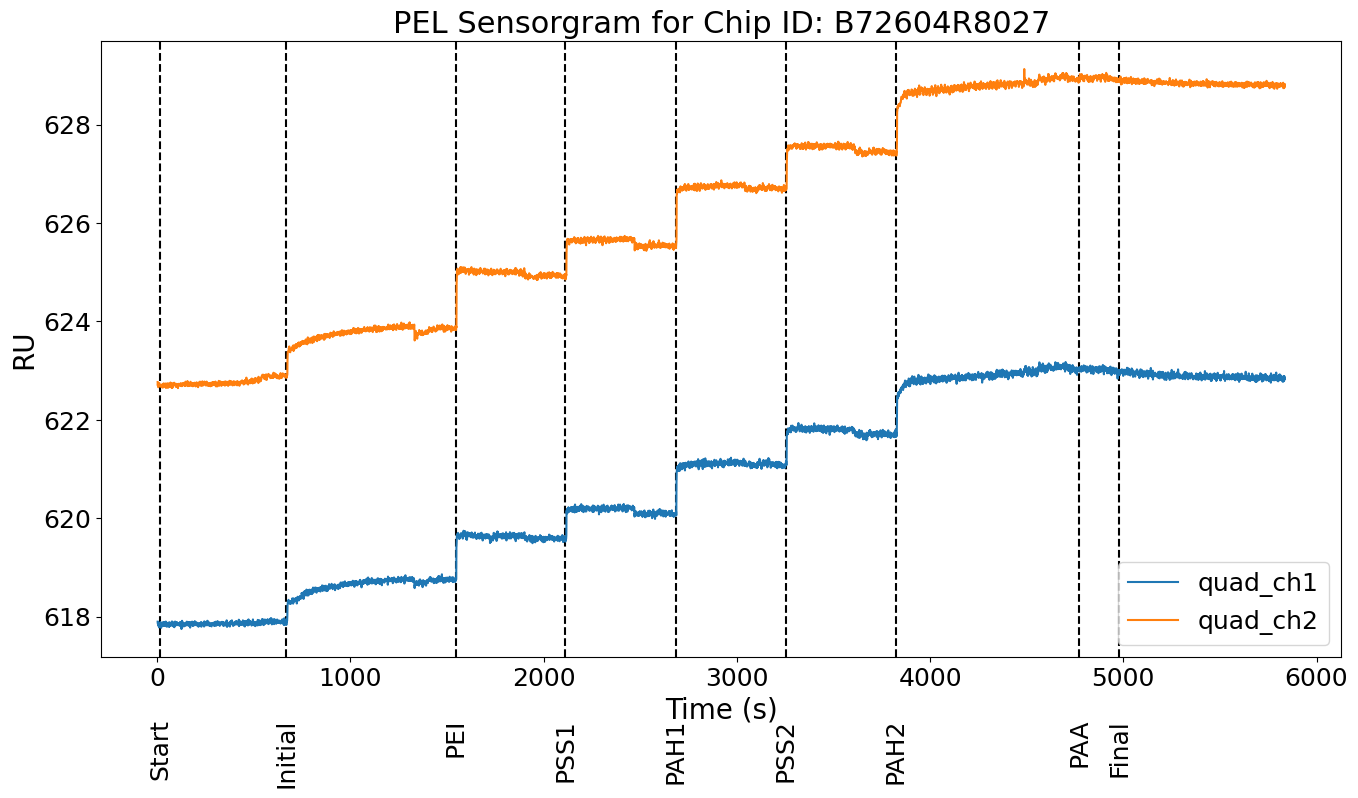

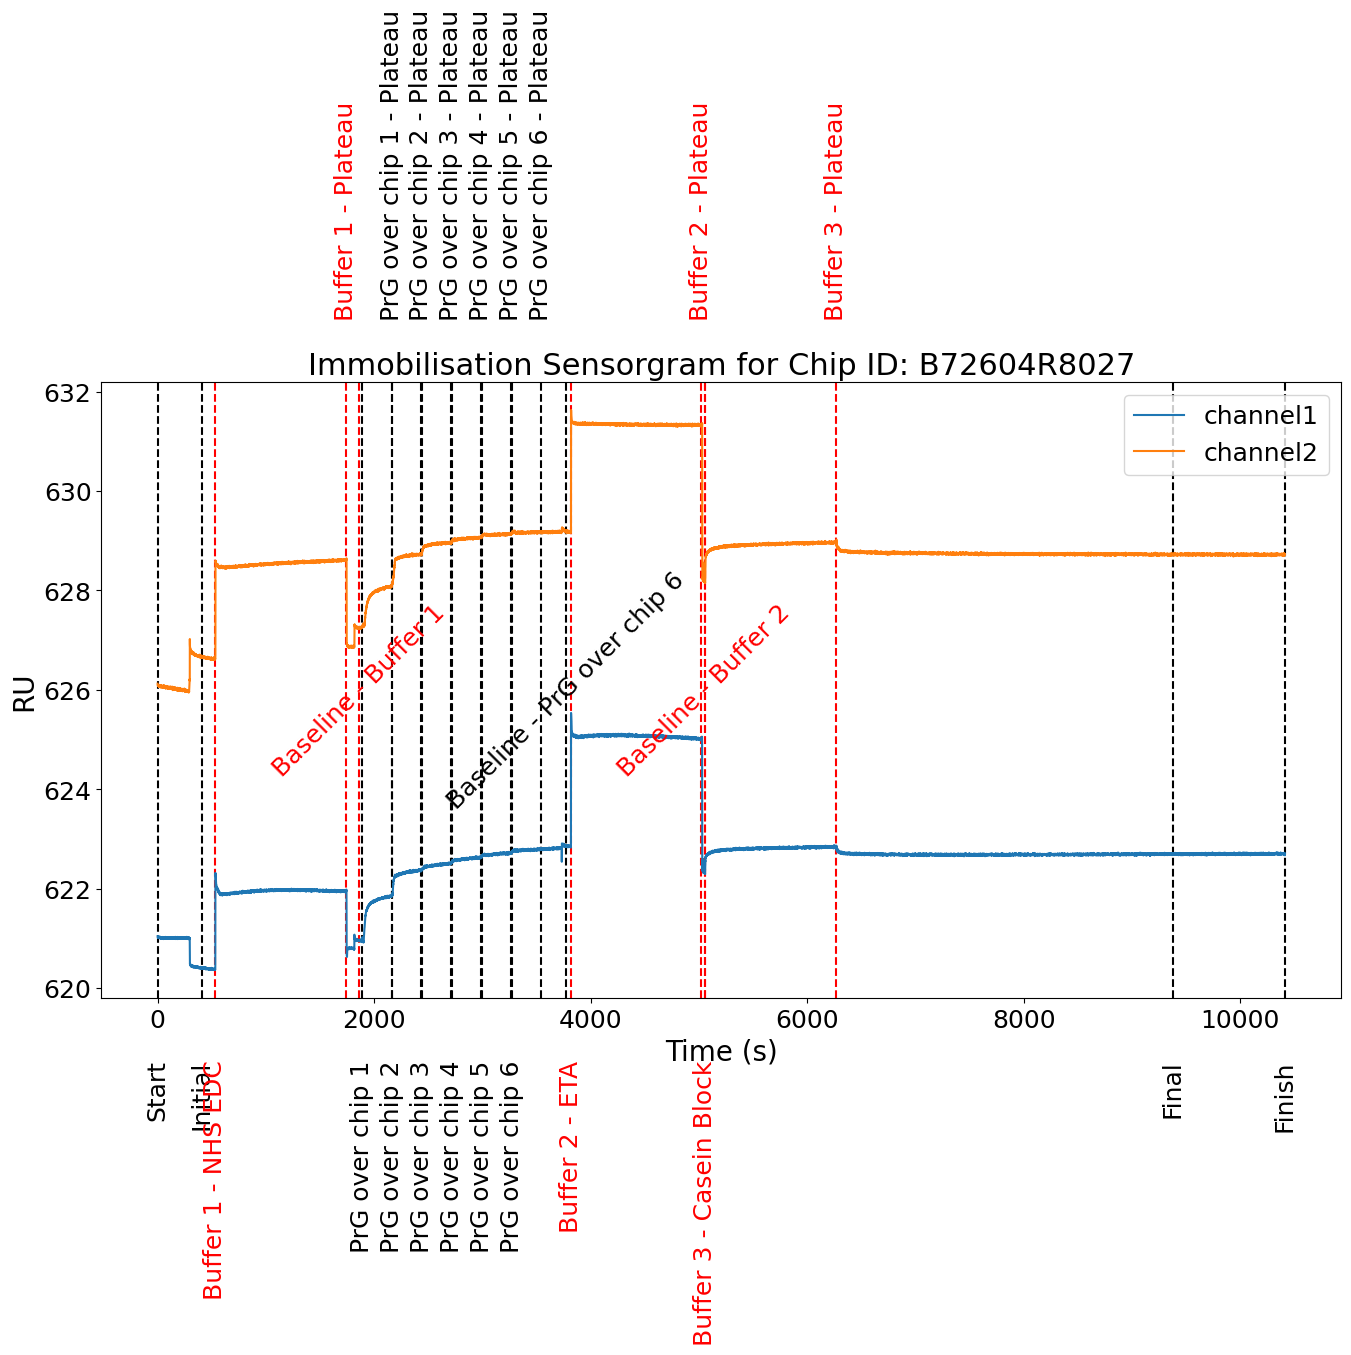

In [136]:
for row in tables['pel_upload'].itertuples():

    if row.chip_id != 'B72604R8027':
        continue

    pel_sensorgram = bucket_data['Sensorgram'].get(row.sensorgram)

    flags_df = tables['flags'][tables['flags']['flags_id'] == row.flags_id]
    times = flags_df.iloc[0][1:].tolist()
    flags_list = flags_df.columns[1:].tolist()

    immob = tables['immob'][tables['immob']['chip_id'] == row.chip_id]

    if immob.empty:
        continue

    try:
        ref_key = immob['refPoly4'].iloc[0]
        amf_key = immob['amfFlags'].iloc[0]
        
        immob_sens = bucket_data['RefPoly4'].get(ref_key)
        immob_flags = bucket_data['AMF_FLAGS'].get(amf_key)
    except Exception as e:
        
        print(f'Failed to get immob files for row {row.Index}: {e}')
        continue

    sc = tables['standard_curves'][tables['standard_curves']['chip_id'] == row.chip_id]

    if pel_sensorgram.empty or sc.empty or immob.empty:
        continue

    for i in range(len(times)):
        if flags_list[i] == 'Finish':
            if times[i] == times[i-1]:
                times = times[:-1]
                flags_list = flags_list[:-1]
                flags_list[-1] = 'Final / Finish'
                break

    plot_flags_on_sensorgrams(pel_sensorgram, times, flags_list, title = 'PEL Sensorgram for Chip ID: ' + row.chip_id)
    plot_flags_on_sensorgrams(immob_sens, immob_flags['time'], immob_flags['information'], title = 'Immobilisation Sensorgram for Chip ID: ' + row.chip_id, colours=['r' if 'Buffer' in str(lbl) else 'k' for lbl in immob_flags['information']])